In [24]:
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [80]:
data_save_path = r"C:\Users\legen\Desktop\Lab Project\ESG\data"

df = pd.read_csv(data_save_path + r"\univ_esg_text_dataset.csv", encoding="utf-8-sig")

print("원본 shape:", df.shape)
print(df["page_type"].value_counts(dropna=False).head(10))

원본 shape: (4563, 8)
page_type
notice           2602
research          777
etc               310
faculty_index     204
student           173
career            154
course            102
curriculum         73
about              72
program            45
Name: count, dtype: int64


# 분석용 page corpus 생성

In [81]:
import os
import re
import hashlib
import numpy as np
import pandas as pd

# =========================
# 1. 기본 정리
# =========================
base_cols = ["university", "college", "department", "page_type", "url", "title", "text", "selector_used"]
for col in base_cols:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

def normalize_text_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\xa0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

df["text"] = df["text"].apply(normalize_text_basic)

df = df.reset_index(drop=True)
df["page_id"] = df.index + 1
df["char_len"] = df["text"].str.len()
df["word_count_rough"] = df["text"].str.split().str.len()

def md5_hash(x: str) -> str:
    return hashlib.md5(x.encode("utf-8", errors="ignore")).hexdigest()

df["text_hash"] = df["text"].apply(md5_hash)

# =========================
# 2. 분석 그룹 분류
# =========================
core_page_types = {
    "about", "research", "career",
    "course", "curriculum", "program", "requirements",
    "student", "activity"
}

# faculty_index는 별도 보류
faculty_page_types = {"faculty_index"}

noise_page_types = {"notice", "board"}

def classify_analysis_group(page_type: str) -> str:
    if page_type in core_page_types:
        return "core"
    elif page_type in faculty_page_types:
        return "faculty_review"
    elif page_type in noise_page_types:
        return "noise"
    else:
        return "review"

df["analysis_group"] = df["page_type"].apply(classify_analysis_group)

In [82]:
# =========================
# 3. 공지/게시판 분리
# =========================
df_noise = df[df["analysis_group"] == "noise"].copy()
df_non_noise = df[df["analysis_group"] != "noise"].copy()

# =========================
# 4. exact duplicate 제거
# - 분석용 페이지에서만 제거
# - 동일 텍스트 반복 제거
# =========================
df_non_noise_dedup = (
    df_non_noise
    .sort_values(["university", "college", "department", "page_type", "url"])
    .drop_duplicates(subset=["text_hash"], keep="first")
    .copy()
)

# =========================
# 5. 너무 짧은 페이지 제거
# - 페이지 단위 분석용 최소 기준
# =========================
MIN_PAGE_CHARS = 120

df_page_core = df_non_noise_dedup[
    (
        (df_non_noise_dedup["analysis_group"] == "core") |
        (df_non_noise_dedup["analysis_group"] == "faculty_review")
    ) &
    (df_non_noise_dedup["char_len"] >= MIN_PAGE_CHARS)
].copy()

df_page_review = df_non_noise_dedup[
    (df_non_noise_dedup["analysis_group"] == "review") |
    (df_non_noise_dedup["char_len"] < MIN_PAGE_CHARS)
].copy()

# =========================
# 6. faculty_index 추가 필터
# - 교수 목록형 페이지 제거
# - 연구/전공설명 포함된 faculty 페이지만 남기기
# =========================
def is_meaningful_faculty_page(title: str, text: str) -> bool:
    t = f"{title} {text}"
    
    positive_patterns = [
        r"연구\s*분야", r"연구분야", r"전공", r"관심\s*분야",
        r"담당\s*교과목", r"학력", r"경력", r"논문", r"publication",
        r"research", r"interest"
    ]
    negative_patterns = [
        r"교수진\s*게시판", r"교수진\s*목록", r"faculty\s*list",
        r"교원\s*목록", r"명단", r"전화번호", r"연락처"
    ]
    
    pos = any(re.search(p, t, flags=re.I) for p in positive_patterns)
    neg = any(re.search(p, t, flags=re.I) for p in negative_patterns)
    
    # 연구 정보가 있으면 유지, 단순 목록형이면 제외
    if pos and not neg:
        return True
    
    # 긍정패턴이 일부 있고 길이가 충분히 길면 유지
    if pos and len(text) >= 300:
        return True
    
    return False

faculty_mask = (df_page_core["analysis_group"] == "faculty_review")

df_page_core["keep_faculty_page"] = True
df_page_core.loc[faculty_mask, "keep_faculty_page"] = df_page_core.loc[faculty_mask].apply(
    lambda r: is_meaningful_faculty_page(r["title"], r["text"]),
    axis=1
)

df_page_core_refined = df_page_core[
    (~faculty_mask) | (df_page_core["keep_faculty_page"])
].copy()

In [83]:
# =========================
# 7. 저장
# =========================
refined_dir = os.path.join(data_save_path, "refined_corpus")
os.makedirs(refined_dir, exist_ok=True)

df_noise.to_csv(os.path.join(refined_dir, "df_noise_notice_board.csv"), index=False, encoding="utf-8-sig")
df_page_core.to_csv(os.path.join(refined_dir, "df_page_core_before_faculty_filter.csv"), index=False, encoding="utf-8-sig")
df_page_core_refined.to_csv(os.path.join(refined_dir, "df_page_core_refined.csv"), index=False, encoding="utf-8-sig")
df_page_review.to_csv(os.path.join(refined_dir, "df_page_review.csv"), index=False, encoding="utf-8-sig")

print("저장 완료:", refined_dir)
print("\n[원본 전체]", df.shape)
print("[공지/게시판]", df_noise.shape)
print("[비공지 중복제거 후]", df_non_noise_dedup.shape)
print("[분석용 페이지 before faculty filter]", df_page_core.shape)
print("[분석용 페이지 refined]", df_page_core_refined.shape)
print("[review]", df_page_review.shape)

print("\npage_type 분포 (refined)")
print(df_page_core_refined["page_type"].value_counts())

저장 완료: C:\Users\legen\Desktop\Lab Project\ESG\data\refined_corpus

[원본 전체] (4563, 13)
[공지/게시판] (2607, 13)
[비공지 중복제거 후] (1703, 13)
[분석용 페이지 before faculty filter] (1385, 14)
[분석용 페이지 refined] (1344, 14)
[review] (318, 13)

page_type 분포 (refined)
page_type
research         688
faculty_index    142
student          129
career           114
course            85
curriculum        58
about             51
program           43
activity          23
requirements      11
Name: count, dtype: int64


## section 분할

In [86]:
# =========================
# 1. 텍스트 정리
# =========================
def normalize_text_for_split(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\xa0", " ")
    text = re.sub(r"[•▪◦·●○◆◇▶▷■□☞]", "\n- ", text)
    text = re.sub(r"\t+", " ", text)
    text = re.sub(r"[ ]{2,}", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

# =========================
# 2. 제외 규칙
# =========================
def looks_like_person_name(line: str) -> bool:
    line = line.strip()
    if len(line) == 0:
        return False
    
    # 한국어 이름 2~4자
    if re.fullmatch(r"[가-힣]{2,4}", line):
        return True
    
    # 영어 이름
    if re.fullmatch(r"[A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,2}", line):
        return True
    
    return False

def is_bad_heading_candidate(line: str) -> bool:
    line = line.strip()
    low = line.lower()
    
    bad_patterns = [
        r"^associate professor$",
        r"^assistant professor$",
        r"^professor$",
        r"^adjunct professor$",
        r"^emeritus professor$",
        r"^조교수$",
        r"^부교수$",
        r"^교수$",
        r"^겸임교수$",
        r"^강사$",
        r"^-\s*",
        r"^[•▪◦·]\s*",
        r"^\(?[0-9]+\)?$",
        r"^[가-힣A-Za-z0-9\s]+@\w+",   # 이메일 느낌
        r"^\d{2,4}[-]\d{2,4}[-]\d{4}$"  # 전화번호
    ]
    
    if looks_like_person_name(line):
        return True
    
    for p in bad_patterns:
        if re.fullmatch(p, line, flags=re.I):
            return True
    
    return False

# =========================
# 3. heading 판별 규칙 강화
# =========================
def is_heading_line_strict(line: str) -> bool:
    if not line:
        return False
    
    line = line.strip()
    if len(line) == 0:
        return False
    
    # 너무 짧거나 너무 길면 제외
    if len(line) < 2 or len(line) > 35:
        return False
    
    # 불량 heading 후보 제외
    if is_bad_heading_candidate(line):
        return False
    
    # 문장 종결이면 제외
    if re.search(r"[.!?]$|[다요니다]$", line):
        return False
    
    # 명시적 구조 신호
    explicit_patterns = [
        r"^\d+[.)]\s*",                          # 1. / 1)
        r"^[가-힣A-Za-z]\.\s*",                  # 가. / A.
        r"^[ⅠⅡⅢⅣⅤⅥⅦⅧⅨⅩ]+\.",                  # Ⅰ.
        r".+:\s*$",                              # 제목:
        r"^(학과소개|전공소개|학부소개|학과 개요|전공 개요)$",
        r"^(교육목표|교육 목적|교육내용|인재상|비전|목표)$",
        r"^(교과과정|교육과정|커리큘럼|교과목|전공과목)$",
        r"^(졸업 후 진로|졸업후 진로|진로|취업 분야|자격증)$",
        r"^(교수소개|교수진|연구실|연구 분야|연구분야|연구영역)$",
        r"^(학생활동|학과활동|비교과|프로그램|현장실습)$",
        r"^(개요|소개|특징|연계전공|복수전공|융합전공)$",
        r"^(주요 내용|세부 내용|지원 자격|지원 방법|운영 내용)$"
    ]
    
    for p in explicit_patterns:
        if re.search(p, line):
            return True
    
    return False

# =========================
# 4. section split
# =========================
def split_sections_refined(text: str, title: str = ""):
    text = normalize_text_for_split(text)
    if not text:
        return []
    
    lines = [ln.strip() for ln in text.split("\n")]
    lines = [ln for ln in lines if ln != ""]
    
    if not lines:
        return []
    
    sections = []
    current_title = title if title else "본문"
    current_lines = []
    found_heading = False
    
    for line in lines:
        if is_heading_line_strict(line):
            if current_lines:
                sec_text = "\n".join(current_lines).strip()
                if sec_text:
                    sections.append({
                        "section_title": current_title,
                        "section_text": sec_text,
                        "split_method": "strict_heading"
                    })
            current_title = line
            current_lines = []
            found_heading = True
        else:
            current_lines.append(line)
    
    if current_lines:
        sec_text = "\n".join(current_lines).strip()
        if sec_text:
            sections.append({
                "section_title": current_title,
                "section_text": sec_text,
                "split_method": "strict_heading" if found_heading else "fallback_page"
            })
    
    # fallback
    if len(sections) == 0:
        sections = [{
            "section_title": title if title else "본문",
            "section_text": text,
            "split_method": "fallback_page"
        }]
    
    return sections

In [88]:
# 선택: kss 사용 가능하면 사용
try:
    import kss
    HAS_KSS = True
except Exception:
    HAS_KSS = False

def split_paragraphs_refined(section_text: str):
    text = normalize_text_for_split(section_text)
    if not text:
        return []
    
    paras = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
    
    # 문단이 거의 없으면 줄 단위 완화
    if len(paras) <= 1:
        lines = [ln.strip() for ln in text.split("\n") if ln.strip()]
        temp = []
        buf = []
        for ln in lines:
            buf.append(ln)
            joined = " ".join(buf)
            if len(joined) >= 250 or re.search(r"[.!?]$|[다요니다]\.$", ln):
                temp.append(joined.strip())
                buf = []
        if buf:
            temp.append(" ".join(buf).strip())
        paras = temp
    
    paras = [p for p in paras if len(p) >= 50]
    return paras

def split_sentences_kr(text: str):
    text = normalize_text_for_split(text)
    if not text:
        return []
    
    if HAS_KSS:
        try:
            sents = kss.split_sentences(text)
            return [s.strip() for s in sents if s.strip()]
        except Exception:
            pass
    
    sents = re.split(r"(?<=[.!?]|다\.|요\.|니다\.)\s+|(?<=\n)", text)
    return [s.strip() for s in sents if s.strip()]

def chunk_sentences_refined(sent_list, min_chars=100, max_chars=450, target_n_sent=3):
    chunks = []
    buf = []
    
    for sent in sent_list:
        candidate = " ".join(buf + [sent]).strip()
        if len(candidate) > max_chars and buf:
            chunks.append(" ".join(buf).strip())
            buf = [sent]
        else:
            buf.append(sent)
        
        if len(buf) >= target_n_sent and len(" ".join(buf)) >= min_chars:
            chunks.append(" ".join(buf).strip())
            buf = []
    
    if buf:
        last = " ".join(buf).strip()
        if last:
            chunks.append(last)
    
    # 너무 짧은 chunk는 앞 chunk에 병합
    merged = []
    for ch in chunks:
        if merged and len(ch) < 70:
            merged[-1] = (merged[-1] + " " + ch).strip()
        else:
            merged.append(ch)
    
    return [m for m in merged if len(m) >= 50]

In [89]:
# =========================
# 1. refined section 생성
# =========================
section_rows = []

for _, row in df_page_core_refined.iterrows():
    sections = split_sections_refined(row["text"], title=row["title"])
    
    for sec_idx, sec in enumerate(sections, start=1):
        section_rows.append({
            "page_id": row["page_id"],
            "section_id": f"{row['page_id']}_S{sec_idx}",
            "section_idx": sec_idx,
            "university": row["university"],
            "college": row["college"],
            "department": row["department"],
            "page_type": row["page_type"],
            "analysis_group": row["analysis_group"],
            "url": row["url"],
            "page_title": row["title"],
            "selector_used": row["selector_used"],
            "section_title": sec["section_title"],
            "section_text": sec["section_text"],
            "section_char_len": len(sec["section_text"]),
            "section_word_count_rough": len(sec["section_text"].split()),
            "section_split_method": sec["split_method"]
        })

df_section_refined = pd.DataFrame(section_rows)

# 너무 짧은 section 제거
MIN_SECTION_CHARS = 80
df_section_refined["keep_section"] = df_section_refined["section_char_len"] >= MIN_SECTION_CHARS

print("df_section_refined shape:", df_section_refined.shape)
print(df_section_refined[["section_id", "page_title", "section_title", "section_char_len"]].head(15))

df_section_refined shape: (2748, 17)
   section_id page_title                   section_title  section_char_len
0     2498_S1    건국대학교 -                         건국대학교 -               131
1     2498_S2    건국대학교 -                           가. 일시               102
2     2498_S3    건국대학교 -    나. 장소: 소속 단과대학 행정실 또는 학과 사무실                63
3     2498_S4    건국대학교 -      다. 각 대학 행정실 전화번호: 450-****               147
4     2498_S5    건국대학교 -                   3. 학위수여식 참고사항               141
5     2498_S6    건국대학교 -          가. 조회방법 : 학사정보시스템에서 확인               311
6     2499_S1    건국대학교 -                         건국대학교 -               383
7     2499_S2    건국대학교 -  1. 수강신청시 시간표에 나와있는 과목번호로 신청할 것               389
8     2502_S1    건국대학교 -                         건국대학교 -               391
9     2475_S1       교육과정                            교육과정               201
10    2488_S1    건국대학교 -                         건국대학교 -                80
11    2488_S2    건국대학교 -               1. 원전공 이수구분 정정 과정       

In [90]:
# =========================
# 2. refined chunk 생성
# - 긴 section만 추가 분할
# =========================
chunk_rows = []

for _, row in df_section_refined.iterrows():
    if not row["keep_section"]:
        continue
    
    section_text = row["section_text"]
    
    # 짧거나 중간 길이면 section 그대로 1 chunk
    if len(section_text) <= 500:
        final_chunks = [section_text]
        chunk_method = "section_as_chunk"
    else:
        paras = split_paragraphs_refined(section_text)
        
        if len(paras) == 0:
            sents = split_sentences_kr(section_text)
            final_chunks = chunk_sentences_refined(sents)
            chunk_method = "sentence_chunk_only"
        else:
            final_chunks = []
            chunk_method = "paragraph_then_sentence_chunk"
            
            for p in paras:
                if len(p) <= 500:
                    final_chunks.append(p)
                else:
                    sents = split_sentences_kr(p)
                    sub_chunks = chunk_sentences_refined(sents)
                    final_chunks.extend(sub_chunks)
    
    for chunk_idx, chunk_text in enumerate(final_chunks, start=1):
        chunk_rows.append({
            "page_id": row["page_id"],
            "section_id": row["section_id"],
            "chunk_id": f"{row['section_id']}_C{chunk_idx}",
            "chunk_idx": chunk_idx,
            "university": row["university"],
            "college": row["college"],
            "department": row["department"],
            "page_type": row["page_type"],
            "analysis_group": row["analysis_group"],
            "url": row["url"],
            "page_title": row["page_title"],
            "section_title": row["section_title"],
            "chunk_text": chunk_text,
            "chunk_char_len": len(chunk_text),
            "chunk_word_count_rough": len(chunk_text.split()),
            "chunk_method": chunk_method
        })

df_chunk_refined = pd.DataFrame(chunk_rows)

MIN_CHUNK_CHARS = 80
df_chunk_refined["keep_chunk"] = df_chunk_refined["chunk_char_len"] >= MIN_CHUNK_CHARS

print("df_chunk_refined shape:", df_chunk_refined.shape)
print(df_chunk_refined[["chunk_id", "page_title", "section_title", "chunk_char_len", "chunk_method"]].head(15))

[Kss]: Because there's no supported C++ morpheme analyzer, Kss will take pecab as a backend. :D
For your information, Kss also supports mecab backend.
We recommend you to install mecab or konlpy.tag.Mecab for faster execution of Kss.
Please refer to following web sites for details:
- mecab: https://cleancode-ws.tistory.com/97
- konlpy.tag.Mecab: https://uwgdqo.tistory.com/363

c:\Users\legen\anaconda3\envs\looker\Lib\site-packages\pecab\_tokenizer.py:265: RuntimeWarning: overflow encountered in scalar add
  from_pos_data.costs[idx]
c:\Users\legen\anaconda3\envs\looker\Lib\site-packages\pecab\_tokenizer.py:274: RuntimeWarning: overflow encountered in scalar add
  least_cost += word_cost


df_chunk_refined shape: (7642, 17)
      chunk_id page_title                   section_title  chunk_char_len  \
0   2498_S1_C1    건국대학교 -                         건국대학교 -             131   
1   2498_S2_C1    건국대학교 -                           가. 일시             102   
2   2498_S4_C1    건국대학교 -      다. 각 대학 행정실 전화번호: 450-****             147   
3   2498_S5_C1    건국대학교 -                   3. 학위수여식 참고사항             141   
4   2498_S6_C1    건국대학교 -          가. 조회방법 : 학사정보시스템에서 확인             311   
5   2499_S1_C1    건국대학교 -                         건국대학교 -             383   
6   2499_S2_C1    건국대학교 -  1. 수강신청시 시간표에 나와있는 과목번호로 신청할 것             389   
7   2502_S1_C1    건국대학교 -                         건국대학교 -             391   
8   2475_S1_C1       교육과정                            교육과정             201   
9   2488_S1_C1    건국대학교 -                         건국대학교 -              80   
10  2488_S2_C1    건국대학교 -               1. 원전공 이수구분 정정 과정              96   
11  2488_S3_C1    건국대학교 -                

In [91]:
# =========================
# 3. 저장
# =========================
refined_dir = os.path.join(data_save_path, "refined_corpus")
os.makedirs(refined_dir, exist_ok=True)

df_section_refined.to_csv(
    os.path.join(refined_dir, "df_section_refined.csv"),
    index=False, encoding="utf-8-sig"
)

df_section_refined[df_section_refined["keep_section"]].to_csv(
    os.path.join(refined_dir, "df_section_refined_keep.csv"),
    index=False, encoding="utf-8-sig"
)

df_chunk_refined.to_csv(
    os.path.join(refined_dir, "df_chunk_refined.csv"),
    index=False, encoding="utf-8-sig"
)

df_chunk_refined[df_chunk_refined["keep_chunk"]].to_csv(
    os.path.join(refined_dir, "df_chunk_refined_keep.csv"),
    index=False, encoding="utf-8-sig"
)

print("refined 저장 완료:", refined_dir)

refined 저장 완료: C:\Users\legen\Desktop\Lab Project\ESG\data\refined_corpus


In [92]:
# 섹션 샘플 확인
sample_sections = df_section_refined[df_section_refined["keep_section"]].sample(20, random_state=42)
display(sample_sections[[
    "university", "department", "page_type", "page_title",
    "section_title", "section_char_len", "section_text"
]])

# chunk 샘플 확인
sample_chunks = df_chunk_refined[df_chunk_refined["keep_chunk"]].sample(20, random_state=42)
display(sample_chunks[[
    "university", "department", "page_type", "page_title",
    "section_title", "chunk_char_len", "chunk_method", "chunk_text"
]])

,university,department,page_type,page_title,section_title,section_char_len,section_text
1770,이화여자대학교,식품생명공학과,research,20학번이후 | 이화여자대학교 식품생명공학전공,4.5,301,0\n0\n3\n3\n실험실습실기\n학년/학기\n학수번호\n과목명\n시간\n학점\n...
818,동덕여자대학교,화장품학전공,activity,화장품 산업체 탐방,210.121.137.7,173,2017-10-27 17:49:36\nhttps://cosmetics.dongduk...
1795,이화여자대학교,식품생명공학과,research,담당교수 | 이화여자대학교 식품생명공학전공,담당교수 | 이화여자대학교 식품생명공학전공,102,"김병식 (Byoung Sik Kim, Ph.D.) 교수\n직위\n부교수\n주소\n서..."
1405,숙명여자대학교,식품영양학과,research,교육과정 | 식품영양학과,세부 전공능력:,119,조리 급식 외식 업무 실무능력\n식품개발평가능력\n산학연계능력\n식생활지도 전문 능...
35,건국대학교,식량자원과학과,career,건국대학교 -,건국대학교 -,328,단축 url\n[채용 협조] 대유 영업본부 영업관리 사원 채용(교내지원 서류면제)\...
1394,숙명여자대학교,식품영양학과,program,봉사단 | 학생지원센터,봉사단 | 학생지원센터,2703,사회봉사\n홈\n사회봉사\n봉사단\n사회봉사\n봉사단\n봉사단\n숙명통역봉사단 (S...
974,서울대학교,소비자학과,research,졸업생 인터뷰 - 소비자학과,졸업생 인터뷰 - 소비자학과,2905,졸업생 인터뷰\nQ: 소비자학 전공 졸업생으로서 어떤 보람을 느끼시는지요?\nA: ...
648,덕성여자대학교,식품영양학전공,career,위치 및 연락처 | 학과소개 | 식품영양학전공,위치 및 연락처 | 학과소개 | 식품영양학전공,812,도서관\n메인으로\n식품영양학전공\n학과소개\n교수 소개\n교과 과정\n커뮤니티\n...
2203,인하대학교,소비자학과,course,인하대학교,인하대학교,96,글번호 178825\n작성일 2026.03.23 수정일 2026.03.23 작성자 ...
1028,서울대학교,소비자학과,student,학사일반 Archives - 소비자학과,학사일반 Archives - 소비자학과,228,학사일반\n2026년 랜선나눔캠퍼스 멘토 모집 안내\n관리자 2026-03-16 3...


,university,department,page_type,page_title,section_title,chunk_char_len,chunk_method,chunk_text
4833,연세대학교,의류환경학과,research,생활과학대학 | 학과소개 | 의류환경학과 | 대학원 교과목,생활과학대학 | 학과소개 | 의류환경학과 | 대학원 교과목,216,paragraph_then_sentence_chunk,"이수학점 중 42학점은 본 학과 개설과목으로, 나머지 학점은 지도교수 승인 하에 학..."
1815,덕성여자대학교,의상디자인전공,career,위치 및 연락처 | 학과소개 | 의상디자인전공,위치 및 연락처 | 학과소개 | 의상디자인전공,257,paragraph_then_sentence_chunk,"4호선 수유역 3번 출구에서 간선버스 120번, 163번 버스 이용 '덕성여대입구(..."
4827,연세대학교,의류환경학과,research,생활과학대학 | 학과소개 | 의류환경학과 | 대학원 교과목,생활과학대학 | 학과소개 | 의류환경학과 | 대학원 교과목,248,paragraph_then_sentence_chunk,"석사학위 취득에 필요한 이수학점 중 24학점은 본 학과 개설과목으로, 나머지 학점은..."
5135,이화여자대학교,식품생명공학과,research,담당교수 | 이화여자대학교 식품생명공학전공,담당교수 | 이화여자대학교 식품생명공학전공,272,paragraph_then_sentence_chunk,Univ. of Minnesota 박사후 연구원 (2000.02~2000.12) ㈜...
6866,인하대학교,소비자학과,research,학생회 소개,학생회 소개,186,section_as_chunk,제 42대 학생회 ‘SO:ONE’\n소비자학과 제 42대 학생회 SO:ONE\n“소...
4433,숙명여자대학교,의류학과,research,교과과정 | 의류학과,교과과정 | 의류학과,82,paragraph_then_sentence_chunk,FABRICATION IN TEXTILE PROCESS 전공(대학원) 석사 3/2....
2085,동덕여자대학교,패션디자인전공,career,"[IDP 유학박람회] 2024 캐나다 유학박람회 (7/13, 코엑스)",58.29.72.209,254,paragraph_then_sentence_chunk,- IDP 캐나다/호주 전문 카운셀러의 정확하고 빠른 입학 수속대행 - 국가별 현지...
3511,서울여자대학교,아동학과,faculty_index,서울여자대학교 아동학과,서울여자대학교 아동학과,251,paragraph_then_sentence_chunk,"이화여자대학교 (문학사, 문학석사) Indiana University (Ph.D) ..."
7139,인하대학교,의류디자인학과,research,인하대학교,다. 장 소 : 비대면 운영,286,paragraph_then_sentence_chunk,라. 인 원 : 최대 208명 (매회 1:1 또는 1:4 비율로 직무특강 진행) 마...
2413,서울대학교,생활과학대학,student,"2월 26, 2026 - 생활과학대학","2월 26, 2026 - 생활과학대학",299,paragraph_then_sentence_chunk,제80회 전기 생활과학대학 박사학위 후드 착의식 (26.2.25.) 2026년 2월...


## 2차 필터링

In [93]:
# =========================
# 0. 데이터 불러오기
# =========================
data_save_path = r"C:\Users\legen\Desktop\Lab Project\ESG\data"
refined_dir = os.path.join(data_save_path, "refined_corpus")

df_section = pd.read_csv(
    os.path.join(refined_dir, "df_section_refined_keep.csv"),
    encoding="utf-8-sig"
).copy()

df_chunk = pd.read_csv(
    os.path.join(refined_dir, "df_chunk_refined_keep.csv"),
    encoding="utf-8-sig"
).copy()

for col in df_section.columns:
    if df_section[col].dtype == "object":
        df_section[col] = df_section[col].fillna("").astype(str).str.strip()

for col in df_chunk.columns:
    if df_chunk[col].dtype == "object":
        df_chunk[col] = df_chunk[col].fillna("").astype(str).str.strip()

# =========================
# 1. 비핵심 페이지 판별 규칙
# =========================
NOISE_TITLE_PATTERNS = [
    r"위치\s*및\s*연락처",
    r"연락처",
    r"오시는\s*길",
    r"포토갤러리",
    r"갤러리",
    r"공지",
    r"학사일반\s*archives",
    r"archives",
    r"게시판",
    r"게시물",
    r"채용",
    r"채용공고",
    r"유학박람회",
    r"박람회",
    r"개인정보처리방침",
    r"privacy",
    r"취업정보",
    r"세미나\s*참여\s*신청",
    r"신청\s*안내",
    r"프로그램\s*신청",
    r"행사\s*안내",
    r"일정\s*안내",
    r"서포터즈\s*활동",
    r"내규",
    r"시행세칙",
    r"규정",
    r"게시판목록",
    r"목록"
]

# 유지하고 싶은 핵심 페이지 신호
CORE_TITLE_PATTERNS = [
    r"학과소개", r"전공소개", r"학부소개",
    r"교육목표", r"인재상", r"비전",
    r"교과과정", r"교육과정", r"교과목", r"교과목\s*소개",
    r"졸업\s*후\s*진로", r"진로",
    r"연구분야", r"연구실", r"교수소개",
    r"복수전공", r"부전공",
    r"학생회\s*소개",
    r"졸업생\s*인터뷰",
    r"전공능력"
]

# 본문 기준 잡음 신호
NOISE_TEXT_PATTERNS = [
    r"작성일",
    r"조회수",
    r"등록일",
    r"글번호",
    r"이전글",
    r"다음글",
    r"첨부파일",
    r"관리자",
    r"수정일",
    r"공지사항",
    r"지원\s*방법",
    r"신청\s*기간",
    r"접수\s*방법",
    r"오시는\s*길",
    r"전화번호",
    r"팩스",
    r"이메일",
    r"개인정보의\s*처리",
    r"보유기간",
    r"동의",
    r"프로그램명",
    r"기간\s*&\s*장소",
    r"박람회",
    r"채용공고",
    r"게시물"
]

# 본문 기준 핵심 신호
CORE_TEXT_PATTERNS = [
    r"교육목표", r"인재상", r"비전",
    r"전공", r"교과과정", r"교과목", r"이수학점",
    r"졸업", r"진로",
    r"연구분야", r"연구", r"실험실", r"연구실",
    r"소비자", r"생활", r"가족", r"식품", r"영양", r"의류", r"아동",
    r"학생회", r"졸업생", r"인터뷰",
    r"현장실습", r"국제교류"
]

def has_any_pattern(text: str, patterns: list) -> bool:
    if not isinstance(text, str):
        return False
    return any(re.search(p, text, flags=re.I) for p in patterns)

def classify_noise_or_core(page_title: str, url: str, text: str) -> dict:
    combined_title = f"{page_title} {url}"
    
    title_noise = has_any_pattern(combined_title, NOISE_TITLE_PATTERNS)
    title_core = has_any_pattern(combined_title, CORE_TITLE_PATTERNS)
    
    text_noise = has_any_pattern(text, NOISE_TEXT_PATTERNS)
    text_core = has_any_pattern(text, CORE_TEXT_PATTERNS)
    
    # 기본 원칙:
    # 1) 제목에서 핵심 신호가 명확하면 우선 유지
    # 2) 제목에서 잡음 신호가 강하고 본문 핵심 신호가 없으면 제거
    # 3) 본문 잡음만 많고 핵심 신호가 거의 없으면 제거
    if title_core:
        keep = True
        reason = "core_title"
    elif title_noise and not text_core:
        keep = False
        reason = "noise_title_no_core_text"
    elif text_noise and not text_core and len(text) < 500:
        keep = False
        reason = "noise_text_short"
    else:
        keep = True
        reason = "default_keep"
    
    return {
        "keep_record": keep,
        "filter_reason": reason,
        "title_noise": title_noise,
        "title_core": title_core,
        "text_noise": text_noise,
        "text_core": text_core
    }


In [94]:
# =========================
# 2. section_title 정리
# =========================
def is_bad_section_title(title: str) -> bool:
    if not isinstance(title, str):
        return True
    
    title = title.strip()
    if title == "":
        return True
    
    # 숫자 / 날짜 / 점수 / IP / 코드
    bad_patterns = [
        r"^\d+(\.\d+)?$",                         # 4 / 4.5
        r"^\d{4}\.\d{2}\.\d{2}$",                # 2026.01.07
        r"^\d{4}-\d{2}-\d{2}$",
        r"^\d{1,3}(\.\d{1,3}){3}$",              # IP
        r"^[A-Za-z]*\d+[A-Za-z\d\-]*$",          # code-like
        r"^[-•▪◦·]+$"
    ]
    
    for p in bad_patterns:
        if re.fullmatch(p, title):
            return True
    
    return False

df_section["section_title_clean"] = df_section["section_title"]
df_section.loc[
    df_section["section_title_clean"].apply(is_bad_section_title),
    "section_title_clean"
] = df_section["page_title"]

df_chunk["section_title_clean"] = df_chunk["section_title"]
df_chunk.loc[
    df_chunk["section_title_clean"].apply(is_bad_section_title),
    "section_title_clean"
] = df_chunk["page_title"]

# =========================
# 3. 2차 필터 적용
# =========================
section_meta = df_section.apply(
    lambda r: classify_noise_or_core(r["page_title"], r["url"], r["section_text"]),
    axis=1
)
section_meta = pd.DataFrame(section_meta.tolist())

df_section_2nd = pd.concat([df_section.reset_index(drop=True), section_meta], axis=1)

chunk_meta = df_chunk.apply(
    lambda r: classify_noise_or_core(r["page_title"], r["url"], r["chunk_text"]),
    axis=1
)
chunk_meta = pd.DataFrame(chunk_meta.tolist())

df_chunk_2nd = pd.concat([df_chunk.reset_index(drop=True), chunk_meta], axis=1)

# =========================
# 4. 최종 keep
# =========================
# section/chunk 길이 최소 기준 추가
MIN_SECTION_FINAL = 100
MIN_CHUNK_FINAL = 100

df_section_final = df_section_2nd[
    (df_section_2nd["keep_record"]) &
    (df_section_2nd["section_char_len"] >= MIN_SECTION_FINAL)
].copy()

df_chunk_final = df_chunk_2nd[
    (df_chunk_2nd["keep_record"]) &
    (df_chunk_2nd["chunk_char_len"] >= MIN_CHUNK_FINAL)
].copy()

In [95]:
# =========================
# 5. 전후 비교
# =========================
compare_summary = pd.DataFrame({
    "dataset": ["section_before", "section_after", "chunk_before", "chunk_after"],
    "n_rows": [
        len(df_section),
        len(df_section_final),
        len(df_chunk),
        len(df_chunk_final)
    ],
    "n_university": [
        df_section["university"].nunique(),
        df_section_final["university"].nunique(),
        df_chunk["university"].nunique(),
        df_chunk_final["university"].nunique()
    ],
    "n_department": [
        df_section["department"].nunique(),
        df_section_final["department"].nunique(),
        df_chunk["department"].nunique(),
        df_chunk_final["department"].nunique()
    ]
})

section_page_type_compare = pd.concat([
    df_section["page_type"].value_counts().rename("before"),
    df_section_final["page_type"].value_counts().rename("after")
], axis=1).fillna(0).astype(int)

chunk_page_type_compare = pd.concat([
    df_chunk["page_type"].value_counts().rename("before"),
    df_chunk_final["page_type"].value_counts().rename("after")
], axis=1).fillna(0).astype(int)

# 제거된 샘플 확인용
section_removed = df_section_2nd[~df_section_2nd.index.isin(df_section_final.index)].copy()
chunk_removed = df_chunk_2nd[~df_chunk_2nd.index.isin(df_chunk_final.index)].copy()

In [96]:
# =========================
# 6. 저장
# =========================
final_dir = os.path.join(data_save_path, "final_filter_test")
os.makedirs(final_dir, exist_ok=True)

compare_summary.to_csv(os.path.join(final_dir, "compare_summary.csv"), index=False, encoding="utf-8-sig")
section_page_type_compare.to_csv(os.path.join(final_dir, "section_page_type_compare.csv"), encoding="utf-8-sig")
chunk_page_type_compare.to_csv(os.path.join(final_dir, "chunk_page_type_compare.csv"), encoding="utf-8-sig")

df_section_final.to_csv(os.path.join(final_dir, "df_section_final.csv"), index=False, encoding="utf-8-sig")
df_chunk_final.to_csv(os.path.join(final_dir, "df_chunk_final.csv"), index=False, encoding="utf-8-sig")

section_removed.sample(min(len(section_removed), 100), random_state=42).to_csv(
    os.path.join(final_dir, "section_removed_sample.csv"),
    index=False, encoding="utf-8-sig"
)
chunk_removed.sample(min(len(chunk_removed), 100), random_state=42).to_csv(
    os.path.join(final_dir, "chunk_removed_sample.csv"),
    index=False, encoding="utf-8-sig"
)

print("저장 완료:", final_dir)
print("\n[전후 비교]")
print(compare_summary)

print("\n[section page_type 전후]")
print(section_page_type_compare)

print("\n[chunk page_type 전후]")
print(chunk_page_type_compare)

저장 완료: C:\Users\legen\Desktop\Lab Project\ESG\data\final_filter_test

[전후 비교]
          dataset  n_rows  n_university  n_department
0  section_before    2059            17            47
1   section_after    1714            17            47
2    chunk_before    6947            17            47
3     chunk_after    5797            17            47

[section page_type 전후]
               before  after
page_type                   
research         1028    926
faculty_index     225    213
career            182    117
student           179    117
course            163    116
curriculum        101     94
program            78     58
about              58     40
activity           25     19
requirements       20     14

[chunk page_type 전후]
               before  after
page_type                   
research         4518   3941
faculty_index    1044    885
career            342    219
course            258    166
student           245    167
curriculum        219    189
program           165    1

In [97]:
# 1. 제거 전후 개수
print(compare_summary)

# 2. section 최종 샘플
display(
    df_section_final[[
        "university", "department", "page_type", "page_title",
        "section_title", "section_title_clean", "section_char_len", "section_text"
    ]].sample(20, random_state=42)
)

# 3. chunk 최종 샘플
display(
    df_chunk_final[[
        "university", "department", "page_type", "page_title",
        "section_title", "section_title_clean", "chunk_char_len", "chunk_text"
    ]].sample(20, random_state=42)
)

# 4. 제거된 샘플도 확인
display(
    section_removed[[
        "university", "department", "page_type", "page_title",
        "section_title", "section_char_len", "filter_reason", "section_text"
    ]].sample(min(len(section_removed), 20), random_state=42)
)

          dataset  n_rows  n_university  n_department
0  section_before    2059            17            47
1   section_after    1714            17            47
2    chunk_before    6947            17            47
3     chunk_after    5797            17            47


,university,department,page_type,page_title,section_title,section_title_clean,section_char_len,section_text
1918,인하대학교,의류디자인학과,faculty_index,전임 및 명예교수,전임 및 명예교수,전임 및 명예교수,468,정보변경 안내\n교수소개 명예교수소개\n나영주 교수\n羅英珠\nNA YOUNG JO...
1454,이화여자대학교,소비자학과,research,확장현실(XR) 기반 소비자 경험 효과에 대한 연구 : 의미연결망과 메타분석을 중심...,확장현실(XR) 기반 소비자 경험 효과에 대한 연구 : 의미연결망과 메타분석을 중심...,확장현실(XR) 기반 소비자 경험 효과에 대한 연구 : 의미연결망과 메타분석을 중심...,14937,확장현실(XR) 기반 소비자 경험 효과에 대한 연구 : 의미연결망과 메타분석을 중심...
608,서울대학교,생활과학대학,faculty_index,명예교수 소개 Archives - 생활과학대학,2003. 03. ～ 2005. 02. 한국의류학회 회장,2003. 03. ～ 2005. 02. 한국의류학회 회장,423,상훈\n과학기술 우수논문상 (한국과학기술단체총연합회)(1999.04.30.)\n한국...
1330,이화여자대학교,식품생명공학과,research,담당교수 | 이화여자대학교 식품생명공학전공,담당교수 | 이화여자대학교 식품생명공학전공,담당교수 | 이화여자대학교 식품생명공학전공,423,"이혜성 (Lee, Hye-Seong) 교수\n직위\n교수\n주소\n서울특별시 서대문..."
472,덕성여자대학교,아동가족학전공,research,위치 및 연락처 | 학과소개 | 아동가족학전공,위치 및 연락처 | 학과소개 | 아동가족학전공,위치 및 연락처 | 학과소개 | 아동가족학전공,808,도서관\n메인으로\n아동가족학전공\n학과소개\n교수 소개\n교과 과정\n커뮤니티\n...
1430,이화여자대학교,소비자학과,research,외모관련 태도와 외모관리행동에 관한 비교연구 : 대만과 한국 직장여성을 중심으로 |...,외모관련 태도와 외모관리행동에 관한 비교연구 : 대만과 한국 직장여성을 중심으로 |...,외모관련 태도와 외모관리행동에 관한 비교연구 : 대만과 한국 직장여성을 중심으로 |...,2258,외모관련 태도와 외모관리행동에 관한 비교연구 : 대만과 한국 직장여성을 중심으로\n...
523,동덕여자대학교,아동학과,faculty_index,아동학과 학과내규,아동학과 학과내규,아동학과 학과내규,187,동덕여자대학교 일반대학원 아동\n- 심리학과 내규\n제1조 (목적) 이 내규는 동덕...
1304,이화여자대학교,식품생명공학과,research,연구실소개 | 이화여자대학교 식품생명공학전공,연구실소개 | 이화여자대학교 식품생명공학전공,연구실소개 | 이화여자대학교 식품생명공학전공,330,본 연구실에서는 식품화학을 기초로 식품 내 향미 특성 규명 및 향미 관련 신소재 개...
1973,중앙대학교,식품공학부 식품영양전공,about,중앙대학교 생명공학대학,중앙대학교 생명공학대학,중앙대학교 생명공학대학,301,중앙대 생명공학대학\n대학소개\n학부(과)소개\n학사안내\n입학안내\n알림마당\nE...
520,동덕여자대학교,식품영양학과,research,식품영양학과 졸업자격요건,식품영양학과 졸업자격요건,식품영양학과 졸업자격요건,3026,Home > 학과 > 졸업자격요건\n졸업자격요건\n식품영양학과 졸업시험 안내\n졸업...


,university,department,page_type,page_title,section_title,section_title_clean,chunk_char_len,chunk_text
4485,이화여자대학교,건축학과,research,TEA 2016 Trajectory of Ewha Architecture — 이화여...,TEA 2016 Trajectory of Ewha Architecture — 이화여...,TEA 2016 Trajectory of Ewha Architecture — 이화여...,414,이화여자대학교 건축학과 Menu KO / EN Ewha Womans Universi...
5305,이화여자대학교,소비자학과,research,"한국과 일본의 20, 30대 소비자의 소비가치, SNS 사용행태와 텀블러 구매행동 ...","한국과 일본의 20, 30대 소비자의 소비가치, SNS 사용행태와 텀블러 구매행동 ...","한국과 일본의 20, 30대 소비자의 소비가치, SNS 사용행태와 텀블러 구매행동 ...",331,환경을 고려하는 환경적 가치가 한국과 일본 소비자의 텀블러 구매행동에 정(+)의 영...
980,고려대학교,지속가능생활시스템융합전공,research,고려대학교 4단계 BK21 지속가능생활시스템융합교육연구단 | MAKEathon Se...,고려대학교 4단계 BK21 지속가능생활시스템융합교육연구단 | MAKEathon Se...,고려대학교 4단계 BK21 지속가능생활시스템융합교육연구단 | MAKEathon Se...,174,- 한장짜리 개념 요약 (견본 제공됩니다) - 다음 내용을 포함하여 미리 녹화한 3...
3171,서울여자대학교,아동학과,research,서울여자대학교 아동학과,서울여자대학교 아동학과,서울여자대학교 아동학과,279,1 CD13015 전필 아동학전공진로탐색 1 3 이론 - 집중이수제 2 CD0302...
2621,서울대학교,식품영양학과,research,글로벌영양시스템 연구실 - 식품영양학과,글로벌영양시스템 연구실 - 식품영양학과,글로벌영양시스템 연구실 - 식품영양학과,251,"- 지역사회 기반 영양, 보건, 식량안보 프로그램의 영향 및 경로 평가 - 영양보충..."
1755,동덕여자대학교,식품영양학과,research,식품영양학과 특수대학원,식품영양학과 특수대학원,식품영양학과 특수대학원,381,Home > 대학원 > 특수대학원\n특수대학원\n01\n임상영양학과는 영양관리를 통...
855,고려대학교,가정교육 전공,research,고려대학교 교육대학원 | 석사학위 과정 | 전공소개,고려대학교 교육대학원 | 석사학위 과정 | 전공소개,고려대학교 교육대학원 | 석사학위 과정 | 전공소개,124,ESO 616 일반사회교과교재연구및지도법 - Literature Review and...
1948,서울대학교,생활과학대학,activity,생활대뉴스 Archives - 생활과학대학,생활대뉴스 Archives - 생활과학대학,생활대뉴스 Archives - 생활과학대학,149,"생활과학대학에는 여러 뜻깊은 행사가 있지만, 개인적으로 저는 이 박사학위 후드 착의..."
240,건국대학교,동물자원식품과학 전공,research,장학기금,장학기금,장학기금,211,1억원이상\n5000만원이상\n2000만원이상\n1000만원이상\n500만원이상\n...
2457,서울대학교,소비자학과,student,장학 Archives - 소비자학과,라. 향후 일정(선발 진행상황에 따라 변동 가능),라. 향후 일정(선발 진행상황에 따라 변동 가능),321,- 신규장학생 대학별 배정인원 안내: 4월 중\n- 신규장학생 대학별 선발 및 추천...


,university,department,page_type,page_title,section_title,section_char_len,filter_reason,section_text
1491,이화여자대학교,식품영양학과,program,식품영양학과_2024 식영인의 밤_행사 개최 | 이화여자대학교 식품영양학과,2. 선배님과 함께 하는 저녁식사 (1차 네트워킹),96,default_keep,"- 선배님과 재학생이 한 테이블에서 함께 대화하며 식사 시간을 가졌으며, 사전에 진..."
976,성균관대학교,식품생명공학과,research,성균관대학교 식품생명공학과 | 대학원과정 | 입학안내,가. 석사과정,93,default_keep,국내외 정규대학에서 학사학위를 받은 자 및 취득 예정자\n관련 법령에 의하여 학사학...
1626,인하대학교,소비자학과,career,인하대학교,260316.zip,132,noise_text_short,다음글\n[2026 서울시 매력일자리사업] AI 활용 SNS 마케터 양성 및 취업 ...
1584,인하대학교,바이오식품공학과,course,인하대학교,바. 수강포기 시 포기 사유 입력 필수,240,noise_text_short,- 개인별로 입력한 포기사유 자료는 비공개되며 통계자료로만 활용 예정\n사. 학점 ...
1900,인하대학교,의류디자인학과,course,인하대학교,바. 수강포기 시 포기 사유 입력 필수,241,noise_text_short,- 개인별로 입력한 포기사유 자료는 비공개되며 통계자료로만 활용 예정\n사. 학점 ...
1965,인하대학교,의류디자인학과,student,인하대학교,인하대학교,163,noise_text_short,글번호 171491\n작성일 2026.02.11 수정일 2026.02.11 작성자 ...
1909,인하대학교,의류디자인학과,curriculum,인하대학교,나. 추천기준,152,noise_text_short,"- 학과이해도가 높고 발표능력이 우수하며 성실한 학생(2학년 이상, 휴학생 불가)\..."
1740,인하대학교,소비자학과,student,인하대학교,인하대학교,84,default_keep,글번호 178466\n작성일 2026.03.18 수정일 2026.03.18 작성자 ...
550,동덕여자대학교,패션디자인전공,career,2017학년도 1학기 창업휴학 신청 안내,4. 접수기간 및 접수처,317,noise_title_no_core_text,가) 접수기간 : 2017.1.16.(월) ~ 1.31.(화) 16:00까지\n※ ...
1618,인하대학교,소비자학과,career,인하대학교,인하대학교,97,noise_text_short,글번호 179777\n작성일 2026.04.02 수정일 2026.04.02 작성자 ...


# tagging

In [98]:
data_save_path = r"C:\Users\legen\Desktop\Lab Project\ESG\data"
final_dir = os.path.join(data_save_path, "final_filter_test")

df_section = pd.read_csv(
    os.path.join(final_dir, "df_section_final.csv"),
    encoding="utf-8-sig"
).copy()

df_chunk = pd.read_csv(
    os.path.join(final_dir, "df_chunk_final.csv"),
    encoding="utf-8-sig"
).copy()

for df_ in [df_section, df_chunk]:
    for col in df_.columns:
        if df_[col].dtype == "object":
            df_[col] = df_[col].fillna("").astype(str).str.strip()


In [99]:
# =========================
# 1. 분석 요소(ㄱ~ㅌ)에 대응하는 세부 라벨 정의
# =========================
# content_element:
# (ㄱ) vision_intro
# (ㄴ) promotion_media
# (ㄷ) curriculum_course
# (ㄹ) faculty_lab
# (ㅁ) activity_news
# (ㅂ) research_output
# (ㅅ) linked_program
# (ㅇ) student_alumni
# (ㅈ) career_certificate
# (ㅊ) external_org
# (ㅋ) notice_board_qna
# (ㅌ) student_community
# 기타: other

PATTERNS = {
    "vision_intro": [
        r"학과소개", r"전공소개", r"학부소개", r"대학소개", r"소개",
        r"교육목표", r"비전", r"인재상", r"설립목적", r"개요", r"특징"
    ],
    "promotion_media": [
        r"홍보", r"리플렛", r"브로슈어", r"브로셔", r"포스터", r"동영상", r"영상", r"홍보영상"
    ],
    "curriculum_course": [
        r"교과과정", r"교육과정", r"교과목", r"교과목 소개", r"교수요목", r"강의계획",
        r"실라버스", r"syllabus", r"이수학점", r"전공선택", r"전공필수", r"대학원 교과목",
        r"교과전공", r"교육내용", r"교수요목", r"졸업자격요건", r"졸업 이수 학점"
    ],
    "faculty_lab": [
        r"교수소개", r"교수진", r"전임교수", r"명예교수", r"교원정보",
        r"연구실소개", r"연구실", r"연구 분야", r"연구분야", r"관심 분야", r"담당교수"
    ],
    "activity_news": [
        r"학과 활동", r"학생 활동", r"심포지움", r"심포지엄", r"세미나", r"특강",
        r"행사", r"동향", r"소식", r"뉴스", r"activity", r"special lecture",
        r"생활대뉴스", r"연구소 소식", r"학과소식"
    ],
    "research_output": [
        r"연구", r"연구프로젝트", r"프로젝트", r"논문", r"학위논문", r"도서",
        r"publication", r"논문목록", r"저서", r"연구성과", r"연구소", r"센터",
        r"lab", r"journal", r"박사후", r"박사후 연구원"
    ],
    "linked_program": [
        r"복수전공", r"부전공", r"연계전공", r"융합전공", r"협동과정",
        r"통합과정", r"협동", r"연계", r"융합", r"마이크로 전공", r"교육단"
    ],
    "student_alumni": [
        r"졸업생 인터뷰", r"학생 인터뷰", r"졸업생", r"동문", r"alumni",
        r"학생회 소개", r"재학생", r"학생 이야기", r"인터뷰"
    ],
    "career_certificate": [
        r"진로", r"졸업 후 진로", r"취업 현황", r"자격증", r"취업", r"career",
        r"면허", r"전망", r"직무", r"직업"
    ],
    "external_org": [
        r"관련사이트", r"협회", r"기관", r"협력 기관", r"단체", r"산학연", r"인적교류",
        r"정부기관", r"외부기관", r"링크"
    ],
    "notice_board_qna": [
        r"공지", r"공지사항", r"게시판", r"q&a", r"qna", r"문의",
        r"학사일정", r"일정", r"장학", r"채용", r"박람회", r"신청", r"지원", r"접수",
        r"개인정보처리방침", r"내규", r"시행세칙", r"규정", r"제출서류", r"지도교수 신청"
    ],
    "student_community": [
        r"학생회", r"sns", r"동창회", r"교우회", r"서포터즈", r"학회", r"커뮤니티",
        r"봉사단", r"멘토", r"소모임"
    ]
}

# 세부 라벨 -> 상위 그룹
ELEMENT_TO_GROUP = {
    "vision_intro": "core_narrative",
    "promotion_media": "activity_community",
    "curriculum_course": "core_narrative",
    "faculty_lab": "core_narrative",
    "activity_news": "activity_community",
    "research_output": "core_narrative",
    "linked_program": "core_narrative",
    "student_alumni": "core_narrative",
    "career_certificate": "core_narrative",
    "external_org": "activity_community",
    "notice_board_qna": "admin_noise",
    "student_community": "activity_community",
    "other": "review_needed"
}

# 우선순위
# notice류를 먼저 잡으면 과도하게 admin으로 빠질 수 있으므로
# 핵심 라벨을 우선 인식하고, 마지막에 notice류를 태깅
LABEL_PRIORITY = [
    "vision_intro",
    "curriculum_course",
    "faculty_lab",
    "research_output",
    "linked_program",
    "student_alumni",
    "career_certificate",
    "activity_news",
    "student_community",
    "external_org",
    "promotion_media",
    "notice_board_qna"
]


In [100]:
# =========================
# 2. 보조 함수
# =========================
def normalize_text(x: str) -> str:
    if not isinstance(x, str):
        return ""
    x = x.replace("\r\n", "\n").replace("\r", "\n")
    x = re.sub(r"\s+", " ", x)
    return x.strip().lower()

def count_matches(text: str, patterns: list) -> int:
    score = 0
    for p in patterns:
        if re.search(p, text, flags=re.I):
            score += 1
    return score

def assign_content_element(page_title: str, section_title: str, url: str, text: str, page_type: str = ""):
    combined_title = f"{page_title} {section_title} {url} {page_type}"
    t_title = normalize_text(combined_title)
    t_text = normalize_text(text[:3000])  # 너무 긴 본문은 앞부분 중심
    
    scores = {}
    reasons = {}
    
    for label, pats in PATTERNS.items():
        title_score = count_matches(t_title, pats)
        text_score = count_matches(t_text, pats)
        
        # 제목 신호를 더 강하게 반영
        total_score = title_score * 2 + text_score
        
        scores[label] = total_score
        reasons[label] = {
            "title_score": title_score,
            "text_score": text_score,
            "total_score": total_score
        }
    
    # 최고 점수 찾기
    best_label = "other"
    best_score = 0
    
    for label in LABEL_PRIORITY:
        if scores[label] > best_score:
            best_score = scores[label]
            best_label = label
    
    # 아무 신호도 없으면 other
    if best_score == 0:
        best_label = "other"
    
    # 보정 규칙 1: faculty_index인데 교수/연구실 정보가 있으면 faculty_lab 우선
    if page_type == "faculty_index":
        if scores["faculty_lab"] >= 1:
            best_label = "faculty_lab"
    
    # 보정 규칙 2: curriculum/course인데 curriculum 신호가 있으면 curriculum_course 우선
    if page_type in ["course", "curriculum", "requirements"]:
        if scores["curriculum_course"] >= 1:
            best_label = "curriculum_course"
    
    # 보정 규칙 3: student인데 장학/일정/신청 중심이면 notice로
    if page_type == "student":
        if scores["notice_board_qna"] >= 2 and scores["student_alumni"] == 0 and scores["student_community"] == 0:
            best_label = "notice_board_qna"
    
    # 보정 규칙 4: career인데 취업현황/진로면 유지, 채용/박람회/일정이면 notice
    if page_type == "career":
        if scores["notice_board_qna"] >= 2 and scores["career_certificate"] == 0:
            best_label = "notice_board_qna"
    
    # 보정 규칙 5: research인데 연구실/논문/프로젝트보다 공지성 신호가 강하면 notice
    if page_type == "research":
        core_research_signal = scores["research_output"] + scores["faculty_lab"] + scores["curriculum_course"]
        if scores["notice_board_qna"] >= 2 and core_research_signal == 0:
            best_label = "notice_board_qna"
    
    group = ELEMENT_TO_GROUP.get(best_label, "review_needed")
    
    return best_label, group, best_score, reasons.get(best_label, {})

In [101]:
# =========================
# 3. section 태깅
# =========================
section_results = df_section.apply(
    lambda r: assign_content_element(
        page_title=r.get("page_title", ""),
        section_title=r.get("section_title_clean", r.get("section_title", "")),
        url=r.get("url", ""),
        text=r.get("section_text", ""),
        page_type=r.get("page_type", "")
    ),
    axis=1
)

section_results = pd.DataFrame(
    section_results.tolist(),
    columns=["content_element", "content_group", "match_score", "match_reason"]
)

df_section_tagged = pd.concat([df_section.reset_index(drop=True), section_results], axis=1)

# =========================
# 4. chunk 태깅
# =========================
chunk_results = df_chunk.apply(
    lambda r: assign_content_element(
        page_title=r.get("page_title", ""),
        section_title=r.get("section_title_clean", r.get("section_title", "")),
        url=r.get("url", ""),
        text=r.get("chunk_text", ""),
        page_type=r.get("page_type", "")
    ),
    axis=1
)

chunk_results = pd.DataFrame(
    chunk_results.tolist(),
    columns=["content_element", "content_group", "match_score", "match_reason"]
)

df_chunk_tagged = pd.concat([df_chunk.reset_index(drop=True), chunk_results], axis=1)

# =========================
# 5. 분포표
# =========================
section_element_dist = (
    df_section_tagged["content_element"]
    .value_counts(dropna=False)
    .rename_axis("content_element")
    .reset_index(name="n_rows")
)

section_group_dist = (
    df_section_tagged["content_group"]
    .value_counts(dropna=False)
    .rename_axis("content_group")
    .reset_index(name="n_rows")
)

chunk_element_dist = (
    df_chunk_tagged["content_element"]
    .value_counts(dropna=False)
    .rename_axis("content_element")
    .reset_index(name="n_rows")
)

chunk_group_dist = (
    df_chunk_tagged["content_group"]
    .value_counts(dropna=False)
    .rename_axis("content_group")
    .reset_index(name="n_rows")
)

# =========================
# 6. 핵심 서술군만 추출
# =========================
df_section_core_narrative = df_section_tagged[
    df_section_tagged["content_group"] == "core_narrative"
].copy()

df_chunk_core_narrative = df_chunk_tagged[
    df_chunk_tagged["content_group"] == "core_narrative"
].copy()

# 활동군도 따로 저장
df_section_activity_community = df_section_tagged[
    df_section_tagged["content_group"] == "activity_community"
].copy()

df_chunk_activity_community = df_chunk_tagged[
    df_chunk_tagged["content_group"] == "activity_community"
].copy()

In [102]:
# =========================
# 7. 저장
# =========================
content_dir = os.path.join(data_save_path, "content_group_tagging")
os.makedirs(content_dir, exist_ok=True)

df_section_tagged.to_csv(
    os.path.join(content_dir, "df_section_tagged.csv"),
    index=False, encoding="utf-8-sig"
)
df_chunk_tagged.to_csv(
    os.path.join(content_dir, "df_chunk_tagged.csv"),
    index=False, encoding="utf-8-sig"
)

df_section_core_narrative.to_csv(
    os.path.join(content_dir, "df_section_core_narrative.csv"),
    index=False, encoding="utf-8-sig"
)
df_chunk_core_narrative.to_csv(
    os.path.join(content_dir, "df_chunk_core_narrative.csv"),
    index=False, encoding="utf-8-sig"
)

df_section_activity_community.to_csv(
    os.path.join(content_dir, "df_section_activity_community.csv"),
    index=False, encoding="utf-8-sig"
)
df_chunk_activity_community.to_csv(
    os.path.join(content_dir, "df_chunk_activity_community.csv"),
    index=False, encoding="utf-8-sig"
)

section_element_dist.to_csv(
    os.path.join(content_dir, "section_element_distribution.csv"),
    index=False, encoding="utf-8-sig"
)
section_group_dist.to_csv(
    os.path.join(content_dir, "section_group_distribution.csv"),
    index=False, encoding="utf-8-sig"
)
chunk_element_dist.to_csv(
    os.path.join(content_dir, "chunk_element_distribution.csv"),
    index=False, encoding="utf-8-sig"
)
chunk_group_dist.to_csv(
    os.path.join(content_dir, "chunk_group_distribution.csv"),
    index=False, encoding="utf-8-sig"
)

print("저장 완료:", content_dir)

print("\n[section element distribution]")
print(section_element_dist)

print("\n[section group distribution]")
print(section_group_dist)

print("\n[chunk element distribution]")
print(chunk_element_dist)

print("\n[chunk group distribution]")
print(chunk_group_dist)

print("\nsection core_narrative shape:", df_section_core_narrative.shape)
print("chunk core_narrative shape:", df_chunk_core_narrative.shape)

저장 완료: C:\Users\legen\Desktop\Lab Project\ESG\data\content_group_tagging

[section element distribution]
       content_element  n_rows
0      research_output     333
1     notice_board_qna     261
2    curriculum_course     249
3         vision_intro     241
4          faculty_lab     205
5   career_certificate     148
6       student_alumni      59
7       linked_program      54
8                other      52
9        activity_news      49
10   student_community      44
11        external_org      12
12     promotion_media       7

[section group distribution]
        content_group  n_rows
0      core_narrative    1289
1         admin_noise     261
2  activity_community     112
3       review_needed      52

[chunk element distribution]
       content_element  n_rows
0      research_output    1189
1         vision_intro    1145
2    curriculum_course     939
3          faculty_lab     705
4                other     461
5     notice_board_qna     399
6   career_certificate     364
7  

In [103]:
# core_narrative 샘플
display(
    df_section_core_narrative[[
        "university", "department", "page_type", "page_title",
        "section_title_clean", "content_element", "section_text"
    ]].sample(20, random_state=42)
)

# activity_community 샘플
display(
    df_section_activity_community[[
        "university", "department", "page_type", "page_title",
        "section_title_clean", "content_element", "section_text"
    ]].sample(20, random_state=42)
)

# review_needed 또는 other 샘플
display(
    df_section_tagged[
        df_section_tagged["content_group"] == "review_needed"
    ][[
        "university", "department", "page_type", "page_title",
        "section_title_clean", "content_element", "section_text"
    ]].sample(20, random_state=42)
)

,university,department,page_type,page_title,section_title_clean,content_element,section_text
1459,인하대학교,소비자학과,research,인하대학교,라. 학적부 1부,linked_program,※ 각 서류의 서명란 서명 또는 도장 날인 반드시 확인 후 제출\n※ 부전공/융합전...
1570,인하대학교,의류디자인학과,career,인하대학교,나. 기대효과,career_certificate,"- 자기소개서 문항별 의도와 평가 포인트에 대한 이해를 통해, 직무 연관성이 높은 ..."
587,서울대학교,소비자학과,research,학부활동 - 소비자학과,학부활동 - 소비자학과,student_alumni,학부활동\n소비자학과에서는 학부생이 소비자학 전문인력으로 필요한 연구역량을 개발할 ...
117,건국대학교,동물자원식품과학 전공,research,가금영양학,3. 주요 연구 분야,research_output,닭 전용 항생제 대체제 개발 및 평가\n육계에서 콕시듐 (coccidiosis) 및...
97,건국대학교,동물자원식품과학 전공,research,취업정보,취업정보,career_certificate,RSS 2.0 총 326 개의 게시물이 있습니다.\n게시물\n제목\n작성자\n번호 ...
167,경희대학교,의상학과,research,의상학과 학과소개 생활과학대학,의상학과 학과소개 생활과학대학,vision_intro,안녕하십니까? 경희대학교 의상학과 홈페이지를 방문해주셔서 감사합니다.\n경희대학교 ...
573,서울대학교,소비자학과,research,대학원 워크샵 - 소비자학과,대학원 워크샵 - 소비자학과,research_output,대학원 워크샵\n대학원활동\n소비자학과 대학원에서는 매년 대학원 워크숍을 진행하고 ...
1342,이화여자대학교,아동학과,research,건강가정사 | 이화여자대학교 아동학과,건강가정사 | 이화여자대학교 아동학과,career_certificate,"자격증 소개\n‘건강가정기본법’에 규정된 건강가정사업을 수행하는 전문가로서, 전국 ..."
928,숙명여자대학교,아동복지학부,career,사회복지전문가(사회복지사 2급 자격증) | 아동복지학부,사회복지전문가(사회복지사 2급 자격증) | 아동복지학부,career_certificate,학과안내\n홈\n학과안내\n전공로드맵\n사회복지전문가(사회복지사 2급 자격증)\n학...
72,건국대학교,식품유통공학과,research,건국대학교 -,4) 학위논문 책자 인쇄본은 별도 제작/제출하지 않음,research_output,5) 심사위원은 지도교수와 학과장의 적격여부 검토를 거쳐 대학원위원회에서 최종 승인...


,university,department,page_type,page_title,section_title_clean,content_element,section_text
626,서울대학교,소비자학과,student,학부심포지엄 - 소비자학과,학부심포지엄 - 소비자학과,activity_news,학부심포지엄\n학부활동\n[26회] 뻔뻔한 가격? Fun Fun한 소비!\n지도교수...
884,숙명여자대학교,가족자원경영학과,student,"가족자원경영학과 23학번 김유진, 이미은, 김다은, 윤지민, 정윤지 학생 보건복지부...","가족자원경영학과 23학번 김유진, 이미은, 김다은, 윤지민, 정윤지 학생 보건복지부...",student_community,커뮤니티\n홈\n커뮤니티\n재학생 및 동문소식\n커뮤니티\n재학생 및 동문소식\n재...
284,고려대학교,가정교육과,student,고려대학교 가정교육과 | 커뮤니티 | 학생회,고려대학교 가정교육과 | 커뮤니티 | 학생회,student_community,학생회\nHOME 커뮤니티 학생회\n가정교육과 학생회는\n가정교육과 학생회의 1년 ...
739,서울대학교,아동가족학과,research,학부 심포지엄 - 아동가족학과,학부 심포지엄 - 아동가족학과,activity_news,"학부 심포지엄\n학부 2, 3학년을 주축으로 매년 심포지엄팀을 구성하여 아동가족학 ..."
686,서울대학교,아동가족학과,faculty_index,서울대학교 생활과학대학 아동가족학과 - 아동가족학과,서울대학교 생활과학대학 아동가족학과 - 아동가족학과,promotion_media,아동가족학 최신 저서\n더보기\n아동가족학과의 최신 소식이\n궁금하다면?\n아동가족...
968,숙명여자대학교,아동복지학부,student,학생회 | 아동복지학부,학생회 | 아동복지학부,student_community,학생활동\n홈\n학생활동\n학생회\n학생활동\n학생회\n학생회\n학생회\n안녕하세요...
467,동덕여자대학교,화장품학전공,about,신입생 간담회,신입생 간담회,student_community,2017-06-07 15:51:02\nhttps://cosmetics.dongduk...
325,단국대학교,식품공학과,course,서포터즈 활동 - 대학혁신사업단 - 단국대학교,006.png,student_community,"✈️ 교환학생, 막연하게 고민만 하고 있나요?\n“진짜 가볼 만할까?”\n“비용은 ..."
322,단국대학교,식품공학과,career,서포터즈 활동 - 대학혁신사업단 - 단국대학교,서포터즈 활동 - 대학혁신사업단 - 단국대학교,student_community,대학혁신사업단\nHOME\nDKU\nPORTAL\nsearch\n사업소개\n프로그램...
728,서울대학교,아동가족학과,research,협력기관 - 아동가족학과,협력기관 - 아동가족학과,external_org,협력기관\n아동가족학과 핵심 파트너 기관은 다음과 같습니다.\n- 서울대학교 어린이...


,university,department,page_type,page_title,section_title_clean,content_element,section_text
1083,이화여자대학교,건축학과,student,학생작업 — 이화여자대학교 건축학과,학생작업 — 이화여자대학교 건축학과,other,이화여자대학교 건축학과\nMenu\nKO / EN\nEwha Womans Unive...
1323,이화여자대학교,의류산업학과,curriculum,학과 내 전공트랙 | 이화여자대학교 의류산업학과 Ewha Womans Univers...,학과 내 전공트랙 | 이화여자대학교 의류산업학과 Ewha Womans Univers...,other,Global Fashion Merchandising & Management 트랙\n...
1531,인하대학교,아동심리학과,requirements,인하대학교,인하대학교,other,글번호 171409\n작성일 2026.02.10 수정일 2026.02.10 작성자 ...
680,서울대학교,아동가족학과,about,찾아오시는길 - 아동가족학과,찾아오시는길 - 아동가족학과,other,서울대학교 생활과학대학\n100m\n확대\n축소\n초기화\n로드뷰\n길찾기\n지도 ...
1434,인하대학교,소비자학과,research,인하대학교,인하대학교,other,글번호 178815\n작성일 2026.03.23 수정일 2026.03.23 작성자 ...
289,고려대학교,식품공학과,curriculum,고려대학교 식품공학과 | 학부 | 졸업안내,다. 미등록상태이거나 수정해야 할 경우,other,"- 학적부 기재사항 정정원서 또는 여권사본(학번, 학과, 국문명, 영문명 기재)\n..."
1079,이화여자대학교,건축학과,student,Chupa Chups Sweetverse : CreatiPop! — 이화여자대학교 ...,Chupa Chups Sweetverse : CreatiPop! — 이화여자대학교 ...,other,이화여자대학교 건축학과\nMenu\nKO / EN\nEwha Womans Unive...
1642,중앙대학교,식품공학부 식품영양전공,faculty_index,중앙대학교 식품영양전공,2. 고령화 사회와 맞춤형 영양 필요성 증가,other,고령화 사회로 접어들면서 노인의 건강을 유지하고 삶의 질을 높이기 위한 맞춤형 영양...
141,경희대학교,생활과학대학,about,생활과학대학 위치 및 연락처 생활과학대학,생활과학대학 위치 및 연락처 생활과학대학,other,위치\n(02447) 서울특별시 동대문구 경희대로 26 경희대학교 생활과학대학 - ...
1102,이화여자대학교,식품생명공학과,research,17학번 이후 | 이화여자대학교 식품생명공학전공,17학번 이후 | 이화여자대학교 식품생명공학전공,other,0\n0\n3\n3\n실험실습실기\n타전공\n3/1\n21959\n고급분자생물학\n...


# preprocessing

In [124]:
import os
import re
import math
import pandas as pd
import numpy as np
from collections import Counter

data_save_path = r"C:\Users\legen\Desktop\Lab Project\ESG\data"
input_path = os.path.join(data_save_path, "content_group_tagging", "df_section_tagged.csv")

df = pd.read_csv(input_path, encoding="utf-8-sig").copy()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("").astype(str).str.strip()

# core_narrative만 사용
if "content_group" in df.columns:
    df = df[df["content_group"] == "core_narrative"].copy()

print("초기 shape:", df.shape)

초기 shape: (1289, 28)


In [125]:
# =========================================================
# 1. dead page / bad page 제거
# =========================================================
def is_bad_page(text: str, title: str = "") -> bool:
    combined = f"{title}\n{text}".lower()
    bad_patterns = [
        "요청하신 페이지가 존재하지 않습니다",
        "페이지를 찾을 수 없습니다",
        "존재하지 않습니다",
        "you do not have permission",
        "권한이 없습니다",
        "접근 권한이 없습니다",
        "404",
        "not found",
    ]
    return any(p in combined for p in bad_patterns)

df = df[~df.apply(lambda x: is_bad_page(x["section_text"], x["page_title"]), axis=1)].copy()
df = df[df["section_text"].str.len() >= 100].copy()

print("bad page 제거 후:", df.shape)

bad page 제거 후: (1289, 28)


In [126]:
# =========================================================
# 2. 공통 잡음 제거
# =========================================================
REMOVE_PATTERNS = [
    r"COPYRIGHT\s*\(C\).*?ALL RIGHTS RESERVED\.?",
    r"COPYRIGHT\s*©.*?ALL RIGHT RESERVED\.?",
    r"\(?0\d{1,2}\)?[-\s]?\d{3,4}[-\s]?\d{4}",
    r"FAX\s*[:：]?\s*\d{2,4}[-\s]?\d{3,4}[-\s]?\d{4}",
    r"TEL\s*[:：]?\s*\d{2,4}[-\s]?\d{3,4}[-\s]?\d{4}",
    r"http[s]?://\S+",
    r"www\.\S+",
    r"add 대학정보공시",
    r"rights reserved",
    r"all rights reserved",
    r"journal of",
    r"university of",
]

REMOVE_LITERAL = [
    "로그인", "login", "사이트맵", "sitemap", "english", "전체메뉴",
    "본문 바로가기", "주메뉴 바로가기", "서브메뉴 바로가기", "푸터 바로가기",
    "내용으로 건너뛰기", "검색창 열기", "검색창 닫기",
    "개인정보처리방침", "법적고지", "top", "메인으로 이동", "홈으로",
    "대학소개", "입학정보", "대학생활", "발전기금/홍보",
    "작성일", "수정일", "작성자", "조회수", "등록일", "글번호",
    "이전글", "다음글", "첨부파일", "관리자",
    "학년/학기", "학수번호", "교과목명", "전공선택", "전공필수", "모든학기"
]

def clean_text(text: str) -> str:
    x = str(text)

    for lit in REMOVE_LITERAL:
        x = x.replace(lit, " ")

    for pat in REMOVE_PATTERNS:
        x = re.sub(pat, " ", x, flags=re.IGNORECASE | re.DOTALL)

    x = re.sub(r"[■▶◆●•·]", " ", x)
    x = re.sub(r"[^\w가-힣\s]", " ", x)
    x = re.sub(r"\b\d+\b", " ", x)
    x = re.sub(r"\s+", " ", x).strip()

    return x

df["text_clean"] = df["section_text"].apply(clean_text)
df = df[df["text_clean"].str.len() >= 80].copy()

print("clean_text 후:", df.shape)

clean_text 후: (1267, 29)


In [127]:
# =========================================================
# 3. phrase normalization
# =========================================================
PHRASE_NORMALIZATION = {
    "사회적 책임": "사회적책임",
    "개인정보 보호": "개인정보보호",
    "공급망 관리": "공급망관리",
    "협력사 관리": "협력사관리",
    "법규 준수": "법규준수",
    "기업 지배구조": "기업지배구조",
    "사회적 가치": "사회적가치",
    "디지털 시민성": "디지털시민성",
    "인적 자본": "인적자본",
    "제품 품질": "제품품질",
    "제품 수명주기": "제품수명주기",
    "지속가능 금융": "지속가능금융",
    "녹색 채권": "녹색채권",
    "사회적 채권": "사회적채권",
    "탄소 중립": "탄소중립",
    "제로 웨이스트": "제로웨이스트",
    "순환 경제": "순환경제",
    "동물 복지": "동물복지",
}

def normalize_phrases(text: str) -> str:
    x = text
    for old, new in PHRASE_NORMALIZATION.items():
        x = x.replace(old, new)
    return x

df["text_clean"] = df["text_clean"].apply(normalize_phrases)

# =========================================================
# 4. exact duplicate 제거
# =========================================================
before = len(df)
df = df.drop_duplicates(subset=["text_clean"]).copy()
after = len(df)
print("중복 제거:", before - after, "건")
print("중복 제거 후:", df.shape)

중복 제거: 54 건
중복 제거 후: (1213, 29)


## 토큰화

In [128]:
# =========================================================
# 5. 문서 단위 보강
# =========================================================
df["doc_for_analysis"] = (
    df["page_title"].fillna("").astype(str).str.strip() + " " +
    df["section_title_clean"].fillna("").astype(str).str.strip() + " " +
    df["text_clean"].fillna("").astype(str).str.strip()
).str.strip()

# =========================================================
# 6. 토큰화
# =========================================================
KOREAN_STOPWORDS = {
    "대학", "대학교", "학과", "전공", "학부", "대학원", "생활과학대학",
    "교육", "과정", "교과", "교수", "학생", "소개", "관련", "이수",
    "공지", "공지사항", "홈페이지", "연구", "학년", "학기", "전임", "명예",
    "대상", "운영", "관리", "기초", "심화", "실습", "실험", "세미나",
    "전문", "능력", "함양", "목표", "비전", "과목", "내용", "안내",
    "기준", "통해", "대한", "위한", "경우", "활동", "이론", "실제"
}

try:
    from konlpy.tag import Okt
    okt = Okt()

    def tokenize_korean(text: str):
        tokens = []
        for word, pos in okt.pos(text, norm=True, stem=True):
            if pos in ["Noun", "Adjective", "Verb"]:
                if len(word) >= 2 and word not in KOREAN_STOPWORDS:
                    tokens.append(word)
        return tokens

    print("Okt tokenizer 사용")

except Exception:
    print("Okt 사용 불가 -> regex fallback 사용")

    def tokenize_korean(text: str):
        words = re.findall(r"[가-힣]{2,}", text)
        return [w for w in words if w not in KOREAN_STOPWORDS]

df["tokens"] = df["doc_for_analysis"].apply(tokenize_korean)
df = df[df["tokens"].apply(len) >= 5].copy()

print("토큰화 후:", df.shape)

Okt tokenizer 사용
토큰화 후: (1212, 31)


## stopword

In [129]:
# =========================================================
# 7. stopword 2차 제거
# =========================================================
GENERAL_FUNCTION_STOPWORDS = {
    "하다", "있다", "되다", "이다", "보다", "위하다", "통하다",
    "대하다", "관련", "통해", "경우", "대상", "이후", "이상", "이내",
    "기반", "활용", "사용", "이용", "진행", "운영", "관리", "제공", "포함",
    "구성", "형성", "수행", "실시", "확인", "가능", "방법", "이해"
}

ACADEMIC_ADMIN_STOPWORDS = {
    "신청", "제출", "모집", "지원", "시험", "사항", "공지", "공지사항",
    "학사", "장학", "장학금", "선발", "서류", "기간", "일정", "공고",
    "채용", "수강", "수강신청", "학점", "학위", "졸업", "인정", "회수",
    "담당", "문의", "접수", "안내", "홈페이지", "학교", "캠퍼스", "센터",
    "행정", "종합", "확인", "관리자", "동문", "이메일", "다음", "이전", "보기"
}

DOMAIN_BIAS_STOPWORDS = {
    "소비자", "소비", "아동", "청소년", "가족",
    "식품", "영양", "영양학", "식품영양학",
    "패션", "의류", "의상", "섬유", "디자인",
    "생명공학", "유아교육", "가정교육", "교육대학"
}

extra_stopwords = (
    GENERAL_FUNCTION_STOPWORDS
    | ACADEMIC_ADMIN_STOPWORDS
    | DOMAIN_BIAS_STOPWORDS
)

def remove_extra_stopwords(tokens):
    return [t for t in tokens if t not in extra_stopwords and len(t) >= 2]

df["tokens2"] = df["tokens"].apply(remove_extra_stopwords)
df = df[df["tokens2"].apply(len) >= 5].copy()
df["tokenized_text"] = df["tokens2"].apply(lambda x: " ".join(x))

print("stopword 후:", df.shape)

stopword 후: (1211, 33)


## ESG 사전

In [131]:
# =========================================================
# 8. ESG weak / strong 사전
# =========================================================
ESG_STRONG_DICT = {
    "E": [
        "지속가능", "지속가능성", "친환경", "기후", "탄소", "탄소중립", "저탄소", "탈탄소",
        "탄소발자국", "넷제로", "온실가스", "ghg", "scope", "재활용", "업사이클링",
        "분리배출", "재사용", "제로웨이스트", "순환경제", "생물다양성", "생태계",
        "오염", "미세먼지", "플라스틱", "폐기물", "동물복지", "화학물질", "유해물질",
        "에너지", "태양광", "풍력", "자원절약", "에너지절약", "감축", "보전", "보호"
    ],
    "S": [
        "사회적책임", "인권", "노동권", "권리", "복지", "소비자보호", "개인정보보호",
        "디지털시민성", "다양성", "형평성", "포용성", "포용적", "성평등", "불평등", "공정",
        "지역사회", "사회공헌", "사회적가치", "건강", "안전", "위생", "웰빙", "삶의질",
        "공급망관리", "협력사관리", "이해관계자", "제품품질", "제품수명주기",
        "인적자본", "교육격차", "기회", "임금", "일자리"
    ],
    "G": [
        "esg위원회", "투명성", "공시", "표시제도", "윤리", "윤리경영",
        "반부패", "뇌물방지", "법규준수", "준법", "감사위원회", "이사회",
        "이사회독립성", "독립성", "주주권", "경영진보상", "기업지배구조",
        "주주가치", "기업가치", "의사결정기준", "정보활용", "정보판단",
        "지속가능금융", "녹색채권", "사회적채권", "책임투자", "임팩트투자",
        "스튜어드십코드", "tcfd", "sasb", "gri", "issb"
    ]
}

ESG_WEAK_DICT = {
    "E": ["환경", "그린", "물", "자원", "절약", "실천", "행동"],
    "S": ["사회", "책임", "참여", "보호", "신뢰", "교육", "역량", "훈련", "개발", "공헌", "관계", "돌봄"],
    "G": ["법", "규칙", "정보", "판단", "기준", "협력", "파트너십"]
}

strong_terms = sorted(set(sum(ESG_STRONG_DICT.values(), [])))
weak_terms   = sorted(set(sum(ESG_WEAK_DICT.values(), [])))

def build_term_pattern(term: str):
    escaped = re.escape(term.replace(" ", ""))
    return re.compile(escaped, flags=re.I)

strong_patterns = {term: build_term_pattern(term) for term in strong_terms}
weak_patterns   = {term: build_term_pattern(term) for term in weak_terms}

def count_term_matches(text: str, pattern_dict: dict):
    total_count = 0
    matched_terms = []
    compact_text = text.replace(" ", "")
    for term, pat in pattern_dict.items():
        cnt = len(pat.findall(compact_text))
        if cnt > 0:
            total_count += cnt
            matched_terms.extend([term] * cnt)
    return total_count, len(set(matched_terms)), sorted(set(matched_terms))

def compute_esg_metrics(row_text: str):
    w_total, w_unique_n, w_terms = count_term_matches(row_text, weak_patterns)
    s_total, s_unique_n, s_terms = count_term_matches(row_text, strong_patterns)
    return pd.Series({
        "weak_total": w_total,
        "weak_unique_n": w_unique_n,
        "weak_unique_terms": ", ".join(w_terms),
        "strong_total": s_total,
        "strong_unique_n": s_unique_n,
        "strong_unique_terms": ", ".join(s_terms),
    })

df = pd.concat([df, df["tokenized_text"].apply(compute_esg_metrics)], axis=1)

df["token_len"] = df["tokens2"].apply(len)
df["weak_per_1000t"] = np.where(df["token_len"] > 0, df["weak_total"] / df["token_len"] * 1000, 0)
df["strong_per_1000t"] = np.where(df["token_len"] > 0, df["strong_total"] / df["token_len"] * 1000, 0)
df["esg_total"] = df["weak_total"] + df["strong_total"]
df["esg_per_1000t"] = df["weak_per_1000t"] + df["strong_per_1000t"]
df["strong_share"] = np.where(df["esg_total"] > 0, df["strong_total"] / df["esg_total"], 0)

## n-gram

In [132]:
# =========================================================
# 9. n-gram
# =========================================================
def make_ngrams(tokens, n=2):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)] if len(tokens) >= n else []

unigram_counter = Counter()
bigram_counter = Counter()
trigram_counter = Counter()

for toks in df["tokens2"]:
    unigram_counter.update(toks)
    bigram_counter.update(make_ngrams(toks, 2))
    trigram_counter.update(make_ngrams(toks, 3))

unigram_top = pd.DataFrame(unigram_counter.most_common(50), columns=["term", "freq"])
bigram_top = pd.DataFrame(bigram_counter.most_common(50), columns=["term", "freq"])
trigram_top = pd.DataFrame(trigram_counter.most_common(50), columns=["term", "freq"])

# ESG 포함 n-gram
esg_all_terms = set(strong_terms + weak_terms)

def contains_esg(term: str, esg_terms: set):
    parts = term.split()
    return any(any(k in p for k in esg_terms) for p in parts)

esg_bigram_top = pd.DataFrame(
    sorted([(k, v) for k, v in bigram_counter.items() if contains_esg(k, esg_all_terms)],
           key=lambda x: x[1], reverse=True),
    columns=["term", "freq"]
)

esg_trigram_top = pd.DataFrame(
    sorted([(k, v) for k, v in trigram_counter.items() if contains_esg(k, esg_all_terms)],
           key=lambda x: x[1], reverse=True),
    columns=["term", "freq"]
)

# PMI

In [133]:
# =========================================================
# 10. PMI bigram 후보
# =========================================================
total_unigrams = sum(unigram_counter.values())
total_bigrams = sum(bigram_counter.values())

pmi_rows = []
for term, freq in bigram_counter.items():
    if freq < 3:
        continue
    w1, w2 = term.split()
    p_xy = freq / total_bigrams
    p_x = unigram_counter[w1] / total_unigrams
    p_y = unigram_counter[w2] / total_unigrams
    pmi = math.log2(p_xy / (p_x * p_y)) if p_x > 0 and p_y > 0 else 0
    pmi_rows.append([term, freq, pmi])

pmi_bigram = pd.DataFrame(pmi_rows, columns=["term", "freq", "pmi"])
pmi_bigram = pmi_bigram.sort_values(["pmi", "freq"], ascending=[False, False]).reset_index(drop=True)

# ESG 포함 PMI 후보만 따로
pmi_esg_bigram = pmi_bigram[pmi_bigram["term"].apply(lambda x: contains_esg(x, esg_all_terms))].copy()


In [134]:
# =========================================================
# 11. 대학별 / 학과별 ESG 지표 집계
# =========================================================
univ_summary = (
    df.groupby("university")
      .agg(
          n_docs=("doc_for_analysis", "count"),
          total_tokens=("token_len", "sum"),
          weak_total=("weak_total", "sum"),
          strong_total=("strong_total", "sum")
      )
      .reset_index()
)

univ_summary["weak_per_1000t"] = univ_summary["weak_total"] / univ_summary["total_tokens"] * 1000
univ_summary["strong_per_1000t"] = univ_summary["strong_total"] / univ_summary["total_tokens"] * 1000
univ_summary["esg_per_1000t"] = univ_summary["weak_per_1000t"] + univ_summary["strong_per_1000t"]
univ_summary["strong_share"] = np.where(
    (univ_summary["weak_total"] + univ_summary["strong_total"]) > 0,
    univ_summary["strong_total"] / (univ_summary["weak_total"] + univ_summary["strong_total"]),
    0
)
univ_summary = univ_summary.sort_values(["strong_per_1000t", "esg_per_1000t"], ascending=False)

dept_summary = (
    df.groupby(["university", "department"])
      .agg(
          n_docs=("doc_for_analysis", "count"),
          total_tokens=("token_len", "sum"),
          weak_total=("weak_total", "sum"),
          strong_total=("strong_total", "sum")
      )
      .reset_index()
)

dept_summary["weak_per_1000t"] = dept_summary["weak_total"] / dept_summary["total_tokens"] * 1000
dept_summary["strong_per_1000t"] = dept_summary["strong_total"] / dept_summary["total_tokens"] * 1000
dept_summary["esg_per_1000t"] = dept_summary["weak_per_1000t"] + dept_summary["strong_per_1000t"]
dept_summary["strong_share"] = np.where(
    (dept_summary["weak_total"] + dept_summary["strong_total"]) > 0,
    dept_summary["strong_total"] / (dept_summary["weak_total"] + dept_summary["strong_total"]),
    0
)
dept_summary = dept_summary.sort_values(["strong_per_1000t", "esg_per_1000t"], ascending=False)

In [135]:
# =========================================================
# 12. 저장
# =========================================================
out_dir = os.path.join(data_save_path, "esg_pipeline_outputs")
os.makedirs(out_dir, exist_ok=True)

df.to_csv(os.path.join(out_dir, "df_section_core_pipeline.csv"), index=False, encoding="utf-8-sig")
unigram_top.to_csv(os.path.join(out_dir, "unigram_top50.csv"), index=False, encoding="utf-8-sig")
bigram_top.to_csv(os.path.join(out_dir, "bigram_top50.csv"), index=False, encoding="utf-8-sig")
trigram_top.to_csv(os.path.join(out_dir, "trigram_top50.csv"), index=False, encoding="utf-8-sig")
esg_bigram_top.to_csv(os.path.join(out_dir, "esg_bigram_top.csv"), index=False, encoding="utf-8-sig")
esg_trigram_top.to_csv(os.path.join(out_dir, "esg_trigram_top.csv"), index=False, encoding="utf-8-sig")
pmi_bigram.to_csv(os.path.join(out_dir, "pmi_bigram_all.csv"), index=False, encoding="utf-8-sig")
pmi_esg_bigram.to_csv(os.path.join(out_dir, "pmi_bigram_esg_only.csv"), index=False, encoding="utf-8-sig")
univ_summary.to_csv(os.path.join(out_dir, "university_esg_summary.csv"), index=False, encoding="utf-8-sig")
dept_summary.to_csv(os.path.join(out_dir, "department_esg_summary.csv"), index=False, encoding="utf-8-sig")

print("저장 완료:", out_dir)
print("\n[unigram top 20]")
print(unigram_top.head(20))
print("\n[bigram top 20]")
print(bigram_top.head(20))
print("\n[trigram top 20]")
print(trigram_top.head(20))
print("\n[ESG bigram top 30]")
print(esg_bigram_top.head(30))
print("\n[ESG trigram top 30]")
print(esg_trigram_top.head(30))
print("\n[PMI 높은 ESG bigram top 30]")
print(pmi_esg_bigram.head(30))
print("\n[university ESG summary top 20]")
print(univ_summary.head(20))
print("\n[department ESG summary top 30]")
print(dept_summary.head(30))

저장 완료: C:\Users\legen\Desktop\Lab Project\ESG\data\esg_pipeline_outputs

[unigram top 20]
     term  freq
0      사회  1253
1      분석   962
2      분야   863
3      박사   840
4      상담   833
5      개발   818
6      석사   801
7      한국   787
8      논문   771
9     연구실   753
10     발달   736
11     산업   705
12   생활과학   624
13    교과목   579
14  이화여자대   568
15     환경   541
16   다양하다   532
17     영향   499
18     기술   496
19     정보   486

[bigram top 20]
          term  freq
0        석사 박사   300
1       미치다 영향   196
2       영향 미치다   195
3        인재 양성   132
4        격년 격년   117
5   서울대학교 생활과학   115
6      프로그램 개발   110
7        학술 대회   108
8        지역 사회   107
9       생활 시스템    94
10       보육 교사    93
11     지속 가능하다    89
12      시스템 융합    88
13       발행 연도    87
14       문제 해결    82
15       무단 수집    81
16       수집 거부    81
17       융합 구단    76
18       놀이 치료    72
19       상담 심리    70

[trigram top 20]
           term  freq
0     생활 시스템 융합    84
1      무단 수집 거부    81
2      격년 격년 격년    78
3     시스템 

# semantic network

In [136]:
import os
import re
import itertools
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

import networkx as nx

# =========================================================
# 0. 데이터 불러오기
# =========================================================
data_save_path = r"C:\Users\legen\Desktop\Lab Project\ESG\data"
input_path = os.path.join(data_save_path, "esg_pipeline_outputs", "df_section_core_pipeline.csv")

df = pd.read_csv(input_path, encoding="utf-8-sig").copy()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("").astype(str).str.strip()

print("입력 데이터 shape:", df.shape)

입력 데이터 shape: (1211, 45)


In [137]:
# =========================================================
# 1. ESG weak / strong 사전
# - 이전 코드와 동일 구조
# - 최종 사전 확정 시 여기만 교체하면 됨
# =========================================================
ESG_STRONG_DICT = {
    "E": [
        "지속가능", "지속가능성", "친환경", "기후", "탄소", "탄소중립", "저탄소", "탈탄소",
        "탄소발자국", "넷제로", "온실가스", "ghg", "scope", "재활용", "업사이클링",
        "분리배출", "재사용", "제로웨이스트", "순환경제", "생물다양성", "생태계",
        "오염", "미세먼지", "플라스틱", "폐기물", "동물복지", "화학물질", "유해물질",
        "에너지", "태양광", "풍력", "자원절약", "에너지절약", "감축", "보전", "보호"
    ],
    "S": [
        "사회적책임", "인권", "노동권", "권리", "복지", "소비자보호", "개인정보보호",
        "디지털시민성", "다양성", "형평성", "포용성", "포용적", "성평등", "불평등", "공정",
        "지역사회", "사회공헌", "사회적가치", "건강", "안전", "위생", "웰빙", "삶의질",
        "공급망관리", "협력사관리", "이해관계자", "제품품질", "제품수명주기",
        "인적자본", "교육격차", "기회", "임금", "일자리"
    ],
    "G": [
        "esg위원회", "투명성", "공시", "표시제도", "윤리", "윤리경영",
        "반부패", "뇌물방지", "법규준수", "준법", "감사위원회", "이사회",
        "이사회독립성", "독립성", "주주권", "경영진보상", "기업지배구조",
        "주주가치", "기업가치", "의사결정기준", "정보활용", "정보판단",
        "지속가능금융", "녹색채권", "사회적채권", "책임투자", "임팩트투자",
        "스튜어드십코드", "tcfd", "sasb", "gri", "issb"
    ]
}

ESG_WEAK_DICT = {
    "E": ["환경", "그린", "물", "자원", "절약", "실천", "행동"],
    "S": ["사회", "책임", "참여", "보호", "신뢰", "교육", "역량", "훈련", "개발", "공헌", "관계", "돌봄"],
    "G": ["법", "규칙", "정보", "판단", "기준", "협력", "파트너십"]
}

# flatten
strong_terms = sorted(set(sum(ESG_STRONG_DICT.values(), [])))
weak_terms = sorted(set(sum(ESG_WEAK_DICT.values(), [])))

# strong 우선 매칭을 위해 합치되, 카테고리 정보도 남김
term_meta_rows = []

for dim, terms in ESG_STRONG_DICT.items():
    for t in terms:
        term_meta_rows.append([t, "strong", dim])

for dim, terms in ESG_WEAK_DICT.items():
    for t in terms:
        term_meta_rows.append([t, "weak", dim])

term_meta = pd.DataFrame(term_meta_rows, columns=["term", "strength", "dimension"]).drop_duplicates()
term_meta = term_meta.sort_values(["strength", "term"], ascending=[True, True]).copy()

# term -> meta dict
term_to_strength = dict(zip(term_meta["term"], term_meta["strength"]))
term_to_dimension = dict(zip(term_meta["term"], term_meta["dimension"]))

# 정규식 패턴
def build_term_pattern(term: str):
    escaped = re.escape(term.replace(" ", ""))
    return re.compile(escaped, flags=re.I)

strong_patterns = {term: build_term_pattern(term) for term in strong_terms}
weak_patterns   = {term: build_term_pattern(term) for term in weak_terms}


In [138]:
# =========================================================
# 2. section별 ESG 키워드 추출
# - 강한 표현 우선
# - 한 section 안에서는 unique term set으로 처리
# =========================================================
def extract_esg_terms_from_text(text: str):
    """
    반환:
      matched_terms_unique: section 내 등장한 ESG 키워드 unique list
    """
    if not isinstance(text, str):
        return []

    compact = text.replace(" ", "")
    matched = []

    # strong 먼저
    for term, pat in strong_patterns.items():
        if pat.search(compact):
            matched.append(term)

    # weak 추가
    for term, pat in weak_patterns.items():
        if pat.search(compact):
            matched.append(term)

    # unique
    matched_unique = sorted(set(matched))
    return matched_unique

# 사용 텍스트: tokenized_text 또는 text_clean
if "tokenized_text" in df.columns:
    SOURCE_COL = "tokenized_text"
elif "text_clean" in df.columns:
    SOURCE_COL = "text_clean"
else:
    SOURCE_COL = "doc_for_analysis"

df["esg_terms_in_doc"] = df[SOURCE_COL].apply(extract_esg_terms_from_text)
df["esg_term_n"] = df["esg_terms_in_doc"].apply(len)

# ESG 키워드가 2개 이상인 section만 network용으로 사용
df_net = df[df["esg_term_n"] >= 2].copy()

print("semantic network용 section 수:", df_net.shape[0])

semantic network용 section 수: 757


In [139]:
# =========================================================
# 3. 노드 빈도 / 엣지 빈도 계산
# =========================================================
node_counter = Counter()
edge_counter = Counter()

for terms in df_net["esg_terms_in_doc"]:
    # 노드 빈도: section 등장 횟수
    node_counter.update(terms)

    # 엣지 빈도: 같은 section 안의 공출현
    for a, b in itertools.combinations(sorted(set(terms)), 2):
        edge_counter[(a, b)] += 1

node_table = pd.DataFrame(
    [(k, v) for k, v in node_counter.items()],
    columns=["term", "doc_freq"]
).sort_values("doc_freq", ascending=False).reset_index(drop=True)

node_table["strength"] = node_table["term"].map(term_to_strength)
node_table["dimension"] = node_table["term"].map(term_to_dimension)

edge_table = pd.DataFrame(
    [(a, b, w) for (a, b), w in edge_counter.items()],
    columns=["source", "target", "weight"]
).sort_values("weight", ascending=False).reset_index(drop=True)

print("node 수:", len(node_table))
print("edge 수:", len(edge_table))

node 수: 71
edge 수: 1267


In [140]:
# =========================================================
# 4. 최소 기준 필터
# - 너무 희박한 노드/엣지는 제외
# =========================================================
MIN_NODE_FREQ = 5
MIN_EDGE_WEIGHT = 3

valid_nodes = set(node_table.loc[node_table["doc_freq"] >= MIN_NODE_FREQ, "term"])

edge_table_f = edge_table[
    (edge_table["weight"] >= MIN_EDGE_WEIGHT) &
    (edge_table["source"].isin(valid_nodes)) &
    (edge_table["target"].isin(valid_nodes))
].copy()

# 필터 후 살아남은 노드만 다시 계산
valid_nodes_after_edge = set(edge_table_f["source"]).union(set(edge_table_f["target"]))

node_table_f = node_table[node_table["term"].isin(valid_nodes_after_edge)].copy()

print("필터 후 node 수:", len(node_table_f))
print("필터 후 edge 수:", len(edge_table_f))

필터 후 node 수: 49
필터 후 edge 수: 668


In [141]:
# =========================================================
# 5. NetworkX 그래프 생성
# =========================================================
G = nx.Graph()

# 노드 추가
for _, row in node_table_f.iterrows():
    G.add_node(
        row["term"],
        doc_freq=row["doc_freq"],
        strength=row["strength"],
        dimension=row["dimension"]
    )

# 엣지 추가
for _, row in edge_table_f.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

print("그래프 노드/엣지:", G.number_of_nodes(), G.number_of_edges())

그래프 노드/엣지: 49 668


In [142]:
# =========================================================
# 6. 중심성 계산
# =========================================================
# weight를 거리로 볼지 강도로 볼지 선택해야 함
# 여기서는 중심성 계산 시 weight를 강도로 사용
degree_dict = dict(G.degree(weight="weight"))

betweenness_dict = nx.betweenness_centrality(G, weight=None)  # 빈도 네트워크에서는 우선 unweighted 권장
closeness_dict = nx.closeness_centrality(G)

try:
    eigenvector_dict = nx.eigenvector_centrality_numpy(G, weight="weight")
except Exception:
    eigenvector_dict = {n: np.nan for n in G.nodes()}

node_table_f["degree_weighted"] = node_table_f["term"].map(degree_dict)
node_table_f["betweenness"] = node_table_f["term"].map(betweenness_dict)
node_table_f["closeness"] = node_table_f["term"].map(closeness_dict)
node_table_f["eigenvector"] = node_table_f["term"].map(eigenvector_dict)

node_table_f = node_table_f.sort_values(
    ["degree_weighted", "doc_freq"],
    ascending=False
).reset_index(drop=True)

In [143]:
# =========================================================
# 7. 차원별(E/S/G) 연결 요약
# =========================================================
def get_edge_dim(row):
    d1 = term_to_dimension.get(row["source"], "NA")
    d2 = term_to_dimension.get(row["target"], "NA")
    pair = "-".join(sorted([d1, d2]))
    return pair

edge_table_f["dimension_pair"] = edge_table_f.apply(get_edge_dim, axis=1)

dimension_edge_summary = (
    edge_table_f.groupby("dimension_pair")
    .agg(
        n_edges=("weight", "count"),
        total_weight=("weight", "sum"),
        mean_weight=("weight", "mean")
    )
    .reset_index()
    .sort_values("total_weight", ascending=False)
)


In [144]:
# =========================================================
# 8. 대학별 semantic network도 만들 수 있게 집계 함수 추가
# =========================================================
def build_semantic_network_by_group(df_input, group_col="university", min_node_freq=3, min_edge_weight=2):
    out_rows = []

    for group_name, sub in df_input.groupby(group_col):
        node_c = Counter()
        edge_c = Counter()

        for terms in sub["esg_terms_in_doc"]:
            uniq = sorted(set(terms))
            if len(uniq) < 2:
                continue
            node_c.update(uniq)
            for a, b in itertools.combinations(uniq, 2):
                edge_c[(a, b)] += 1

        node_df = pd.DataFrame([(k, v) for k, v in node_c.items()], columns=["term", "doc_freq"])
        edge_df = pd.DataFrame([(a, b, w) for (a, b), w in edge_c.items()], columns=["source", "target", "weight"])

        if len(node_df) == 0 or len(edge_df) == 0:
            continue

        node_valid = set(node_df.loc[node_df["doc_freq"] >= min_node_freq, "term"])
        edge_df = edge_df[
            (edge_df["weight"] >= min_edge_weight) &
            (edge_df["source"].isin(node_valid)) &
            (edge_df["target"].isin(node_valid))
        ].copy()

        if len(edge_df) == 0:
            continue

        for _, r in edge_df.sort_values("weight", ascending=False).head(30).iterrows():
            out_rows.append([
                group_name, r["source"], r["target"], r["weight"]
            ])

    return pd.DataFrame(out_rows, columns=[group_col, "source", "target", "weight"])

edge_by_university = build_semantic_network_by_group(df_net, group_col="university")
edge_by_department = build_semantic_network_by_group(df_net, group_col="department")

In [145]:
# =========================================================
# 9. 저장
# =========================================================
out_dir = os.path.join(data_save_path, "semantic_network_outputs")
os.makedirs(out_dir, exist_ok=True)

df_net.to_csv(os.path.join(out_dir, "df_semantic_input_sections.csv"), index=False, encoding="utf-8-sig")
node_table.to_csv(os.path.join(out_dir, "semantic_node_table_all.csv"), index=False, encoding="utf-8-sig")
edge_table.to_csv(os.path.join(out_dir, "semantic_edge_table_all.csv"), index=False, encoding="utf-8-sig")

node_table_f.to_csv(os.path.join(out_dir, "semantic_node_table_filtered.csv"), index=False, encoding="utf-8-sig")
edge_table_f.to_csv(os.path.join(out_dir, "semantic_edge_table_filtered.csv"), index=False, encoding="utf-8-sig")
dimension_edge_summary.to_csv(os.path.join(out_dir, "semantic_dimension_edge_summary.csv"), index=False, encoding="utf-8-sig")

edge_by_university.to_csv(os.path.join(out_dir, "semantic_edge_by_university_top30.csv"), index=False, encoding="utf-8-sig")
edge_by_department.to_csv(os.path.join(out_dir, "semantic_edge_by_department_top30.csv"), index=False, encoding="utf-8-sig")

print("저장 완료:", out_dir)

print("\n[상위 노드 30]")
print(node_table_f.head(30))

print("\n[상위 엣지 30]")
print(edge_table_f.head(30))

print("\n[차원별 연결 요약]")
print(dimension_edge_summary)

print("\n[대학별 상위 엣지 샘플]")
print(edge_by_university.head(30))

print("\n[학과별 상위 엣지 샘플]")
print(edge_by_department.head(30))

저장 완료: C:\Users\legen\Desktop\Lab Project\ESG\data\semantic_network_outputs

[상위 노드 30]
     term  doc_freq strength dimension  degree_weighted  betweenness  \
0      사회       358     weak         S             2138     0.044119   
1      개발       311     weak         S             1883     0.062352   
2      환경       242     weak         E             1663     0.046542   
3       물       256     weak         E             1462     0.042935   
4       법       222     weak         G             1435     0.019640   
5      정보       238     weak         G             1420     0.046778   
6      교육       256     weak         S             1341     0.011799   
7      건강       199   strong         S             1323     0.022990   
8      관계       160     weak         S             1170     0.015659   
9      행동       151     weak         E             1135     0.011384   
10     복지       155   strong         S              982     0.011390   
11     안전       131   strong         S          

## 시각화

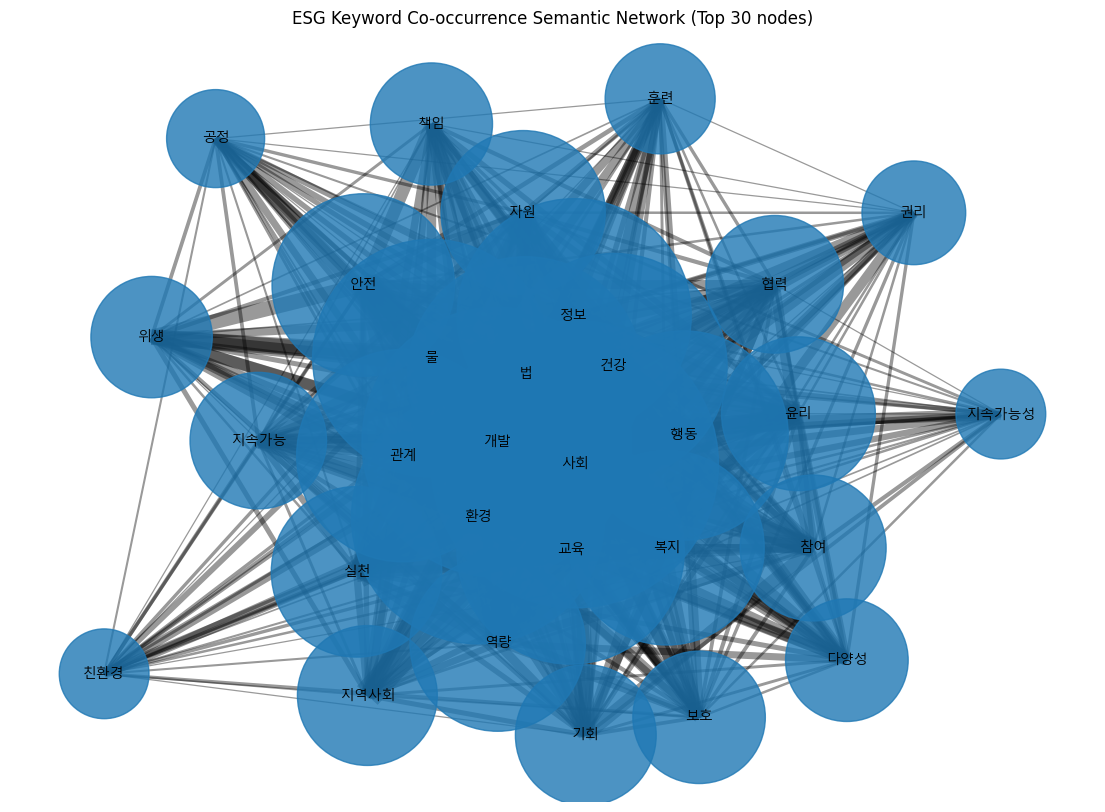

In [146]:
import matplotlib.pyplot as plt

# 상위 노드 30개만 사용
top_nodes = node_table_f.head(30)["term"].tolist()
sub_edges = edge_table_f[
    edge_table_f["source"].isin(top_nodes) &
    edge_table_f["target"].isin(top_nodes)
].copy()

G_sub = nx.Graph()
for _, row in sub_edges.iterrows():
    G_sub.add_edge(row["source"], row["target"], weight=row["weight"])

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_sub, k=0.7, seed=42)

edge_weights = [G_sub[u][v]["weight"] for u, v in G_sub.edges()]
node_sizes = [node_table_f.set_index("term").loc[n, "degree_weighted"] * 20 for n in G_sub.nodes()]

nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(G_sub, pos, width=[w * 0.3 for w in edge_weights], alpha=0.4)
nx.draw_networkx_labels(G_sub, pos, font_family="Malgun Gothic", font_size=10)

plt.title("ESG Keyword Co-occurrence Semantic Network (Top 30 nodes)")
plt.axis("off")
plt.show()

# LDA

In [2]:
import os
import re
import pandas as pd
import numpy as np

from collections import Counter

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# =========================================================
# 0. 데이터 불러오기
# =========================================================
data_save_path = r"C:\Users\legen\Desktop\Lab Project\ESG\data"
content_dir = os.path.join(data_save_path, "content_group_tagging")

df = pd.read_csv(
    os.path.join(content_dir, "df_chunk_core_narrative.csv"),
    encoding="utf-8-sig"
).copy()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("").astype(str).str.strip()

print("초기 shape:", df.shape)

초기 shape: (4653, 28)


In [3]:
# =========================================================
# 1. 기본 텍스트 정제
# =========================================================
REMOVE_PATTERNS = [
    r"http[s]?://\S+",
    r"www\.\S+",
    r"COPYRIGHT\s*\(C\).*?ALL RIGHTS RESERVED\.?",
    r"COPYRIGHT\s*©.*?ALL RIGHT RESERVED\.?",
    r"all rights reserved",
    r"rights reserved",
    r"\(?0\d{1,2}\)?[-\s]?\d{3,4}[-\s]?\d{4}",
    r"FAX\s*[:：]?\s*\d{2,4}[-\s]?\d{3,4}[-\s]?\d{4}",
    r"TEL\s*[:：]?\s*\d{2,4}[-\s]?\d{3,4}[-\s]?\d{4}",
    r"작성일 \d{4}\.\d{2}\.\d{2}",
    r"조회수 \d+",
    r"등록일 \d{4}\.\d{2}\.\d{2}",
    r"글번호 \d+",
]

REMOVE_LITERAL = [
    "로그인", "사이트맵", "영문", "english", "전체메뉴",
    "본문 바로가기", "주메뉴 바로가기", "서브메뉴 바로가기", "푸터 바로가기",
    "내용으로 건너뛰기", "개인정보처리방침", "법적고지",
    "이전글", "다음글", "첨부파일", "관리자",
    "학년/학기", "학수번호", "교과목명", "전공선택", "전공필수", "모든학기",
    "생활과학대학", "홈", "메인으로", "더보기"
]

PHRASE_NORMALIZATION = {
    "사회적 책임": "사회적책임",
    "개인정보 보호": "개인정보보호",
    "공급망 관리": "공급망관리",
    "협력사 관리": "협력사관리",
    "법규 준수": "법규준수",
    "기업 지배구조": "기업지배구조",
    "사회적 가치": "사회적가치",
    "디지털 시민성": "디지털시민성",
    "인적 자본": "인적자본",
    "제품 품질": "제품품질",
    "제품 수명주기": "제품수명주기",
    "지속가능 금융": "지속가능금융",
    "녹색 채권": "녹색채권",
    "사회적 채권": "사회적채권",
    "탄소 중립": "탄소중립",
    "제로 웨이스트": "제로웨이스트",
    "순환 경제": "순환경제",
    "동물 복지": "동물복지",
    "지역 사회": "지역사회",
}

def clean_text(text: str) -> str:
    x = str(text)

    for lit in REMOVE_LITERAL:
        x = x.replace(lit, " ")

    for pat in REMOVE_PATTERNS:
        x = re.sub(pat, " ", x, flags=re.IGNORECASE | re.DOTALL)

    for old, new in PHRASE_NORMALIZATION.items():
        x = x.replace(old, new)

    x = re.sub(r"[■▶◆●•·]", " ", x)
    x = re.sub(r"[^\w가-힣\s]", " ", x)
    x = re.sub(r"\b\d+\b", " ", x)
    x = re.sub(r"\s+", " ", x).strip()

    return x

TEXT_COL = "chunk_text"
df["text_clean"] = df[TEXT_COL].apply(clean_text)
df = df[df["text_clean"].str.len() >= 50].copy()

print("clean_text 후 shape:", df.shape)

clean_text 후 shape: (4647, 29)


In [4]:
# =========================================================
# 2. 토큰화
# =========================================================
try:
    from konlpy.tag import Okt
    okt = Okt()

    def tokenize_korean(text: str):
        tokens = []
        for word, pos in okt.pos(text, norm=True, stem=True):
            if pos in ["Noun", "Adjective", "Verb"]:
                if len(word) >= 2:
                    tokens.append(word)
        return tokens

    print("Okt tokenizer 사용")

except Exception:
    print("Okt 사용 불가 -> regex fallback 사용")

    def tokenize_korean(text: str):
        return re.findall(r"[가-힣]{2,}", text)

df["tokens"] = df["text_clean"].apply(tokenize_korean)

Okt tokenizer 사용


In [5]:
# =========================================================
# 3. stopword 제거
# 방법 B: weak 허브 단어 추가 제거
# =========================================================
BASE_STOPWORDS = {
    "대학", "대학교", "학과", "전공", "학부", "대학원",
    "학생", "교수", "과목", "과정", "소개", "관련",
    "운영", "관리", "내용", "기준", "통해", "위한", "대한",
    "합니다", "있습니다", "한다", "있다", "위해", "경우",
    "분야", "능력", "실습", "실험", "세미나", "안내",
    "학년도", "석사", "박사", "논문", "연구실", "발달", "기술"
}

ACADEMIC_ADMIN_STOPWORDS = {
    "공지", "공지사항", "모집", "지원", "신청", "접수", "제출", "서류",
    "일정", "학사", "장학", "장학금", "수강", "수강신청",
    "문의", "접수", "관리자", "작성자", "조회수", "등록일"
}

DOMAIN_BIAS_STOPWORDS = {
    "소비자", "소비", "아동", "청소년", "가족",
    "식품", "영양", "영양학", "식품영양학",
    "패션", "의류", "의상", "섬유", "디자인",
    "생명공학", "가정교육", "교육대학"
}

# 방법 B 핵심
WEAK_HUB_STOPWORDS = {
    "개발", "교육", "정보", "법", "물"
}

STOPWORDS = BASE_STOPWORDS | ACADEMIC_ADMIN_STOPWORDS | DOMAIN_BIAS_STOPWORDS | WEAK_HUB_STOPWORDS

def remove_stopwords(tokens):
    return [t for t in tokens if len(t) >= 2 and t not in STOPWORDS]

df["tokens2"] = df["tokens"].apply(remove_stopwords)
df = df[df["tokens2"].apply(len) >= 5].copy()

print("stopword 후 shape:", df.shape)


stopword 후 shape: (4130, 31)


In [6]:
# =========================================================
# 4. 너무 희귀/너무 흔한 토큰 제거
# =========================================================
token_doc_counter = Counter()
for toks in df["tokens2"]:
    token_doc_counter.update(set(toks))

n_docs = len(df)

MIN_DOC_FREQ = 5
MAX_DOC_PROP = 0.6

valid_terms = {
    term for term, cnt in token_doc_counter.items()
    if cnt >= MIN_DOC_FREQ and cnt <= n_docs * MAX_DOC_PROP
}

df["tokens3"] = df["tokens2"].apply(lambda toks: [t for t in toks if t in valid_terms])
df = df[df["tokens3"].apply(len) >= 5].copy()

print("희귀/과다빈도 단어 제거 후 shape:", df.shape)

희귀/과다빈도 단어 제거 후 shape: (4121, 32)


In [7]:
# =========================================================
# 5. Gensim dictionary / corpus
# =========================================================
texts = df["tokens3"].tolist()

dictionary = corpora.Dictionary(texts)

# 너무 희귀/흔한 단어 다시 한번 필터
dictionary.filter_extremes(no_below=5, no_above=0.6)

corpus = [dictionary.doc2bow(text) for text in texts]

print("dictionary size:", len(dictionary))
print("corpus size:", len(corpus))

dictionary size: 2905
corpus size: 4121


In [8]:
import os
import re
import pandas as pd
import numpy as np

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# =========================================================
# 0. 데이터 불러오기
# =========================================================
data_save_path = r"C:\Users\legen\Desktop\Lab Project\ESG\data"
content_dir = os.path.join(data_save_path, "content_group_tagging")

df = pd.read_csv(
    os.path.join(content_dir, "df_chunk_core_narrative.csv"),
    encoding="utf-8-sig"
).copy()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("").astype(str).str.strip()

print("초기 shape:", df.shape)

# =========================================================
# 1. 기본 텍스트 정제
# =========================================================
REMOVE_PATTERNS = [
    r"http[s]?://\S+",
    r"www\.\S+",
    r"COPYRIGHT\s*\(C\).*?ALL RIGHTS RESERVED\.?",
    r"COPYRIGHT\s*©.*?ALL RIGHT RESERVED\.?",
    r"all rights reserved",
    r"rights reserved",
    r"\(?0\d{1,2}\)?[-\s]?\d{3,4}[-\s]?\d{4}",
    r"FAX\s*[:：]?\s*\d{2,4}[-\s]?\d{3,4}[-\s]?\d{4}",
    r"TEL\s*[:：]?\s*\d{2,4}[-\s]?\d{3,4}[-\s]?\d{4}",
    r"작성일 \d{4}\.\d{2}\.\d{2}",
    r"조회수 \d+",
    r"등록일 \d{4}\.\d{2}\.\d{2}",
    r"글번호 \d+",
]

REMOVE_LITERAL = [
    "로그인", "사이트맵", "영문", "english", "전체메뉴",
    "본문 바로가기", "주메뉴 바로가기", "서브메뉴 바로가기", "푸터 바로가기",
    "내용으로 건너뛰기", "개인정보처리방침", "법적고지",
    "이전글", "다음글", "첨부파일", "관리자",
    "학년/학기", "학수번호", "교과목명", "전공선택", "전공필수", "모든학기",
    "생활과학대학", "홈", "메인으로", "더보기"
]

PHRASE_NORMALIZATION = {
    "사회적 책임": "사회적책임",
    "개인정보 보호": "개인정보보호",
    "공급망 관리": "공급망관리",
    "협력사 관리": "협력사관리",
    "법규 준수": "법규준수",
    "기업 지배구조": "기업지배구조",
    "사회적 가치": "사회적가치",
    "디지털 시민성": "디지털시민성",
    "인적 자본": "인적자본",
    "제품 품질": "제품품질",
    "제품 수명주기": "제품수명주기",
    "지속가능 금융": "지속가능금융",
    "녹색 채권": "녹색채권",
    "사회적 채권": "사회적채권",
    "탄소 중립": "탄소중립",
    "제로 웨이스트": "제로웨이스트",
    "순환 경제": "순환경제",
    "동물 복지": "동물복지",
    "지역 사회": "지역사회",
}

def clean_text(text: str) -> str:
    x = str(text)

    for lit in REMOVE_LITERAL:
        x = x.replace(lit, " ")

    for pat in REMOVE_PATTERNS:
        x = re.sub(pat, " ", x, flags=re.IGNORECASE | re.DOTALL)

    for old, new in PHRASE_NORMALIZATION.items():
        x = x.replace(old, new)

    x = re.sub(r"[■▶◆●•·]", " ", x)
    x = re.sub(r"[^\w가-힣\s]", " ", x)
    x = re.sub(r"\b\d+\b", " ", x)
    x = re.sub(r"\s+", " ", x).strip()

    return x

TEXT_COL = "chunk_text"
df["text_clean"] = df[TEXT_COL].apply(clean_text)
df = df[df["text_clean"].str.len() >= 50].copy()

print("clean_text 후 shape:", df.shape)

# =========================================================
# 2. 토큰화
# =========================================================
try:
    from konlpy.tag import Okt
    okt = Okt()

    def tokenize_korean(text: str):
        tokens = []
        for word, pos in okt.pos(text, norm=True, stem=True):
            if pos in ["Noun", "Adjective", "Verb"]:
                if len(word) >= 2:
                    tokens.append(word)
        return tokens

    print("Okt tokenizer 사용")

except Exception:
    print("Okt 사용 불가 -> regex fallback 사용")

    def tokenize_korean(text: str):
        return re.findall(r"[가-힣]{2,}", text)

df["tokens"] = df["text_clean"].apply(tokenize_korean)

# =========================================================
# 3. stopword 제거
# =========================================================
BASE_STOPWORDS = {
    "대학", "대학교", "학과", "전공", "학부", "대학원",
    "학생", "교수", "과목", "과정", "소개", "관련",
    "운영", "관리", "내용", "기준", "통해", "위한", "대한",
    "합니다", "있습니다", "한다", "있다", "위해", "경우",
    "분야", "능력", "실습", "실험", "세미나", "안내",
    "학년도", "석사", "박사", "논문", "연구실", "발달", "기술"
}

ACADEMIC_ADMIN_STOPWORDS = {
    "공지", "공지사항", "모집", "지원", "신청", "접수", "제출", "서류",
    "일정", "학사", "장학", "장학금", "수강", "수강신청",
    "문의", "관리자", "작성자", "조회수", "등록일"
}

DOMAIN_BIAS_STOPWORDS = {
    "소비자", "소비", "아동", "청소년", "가족",
    "식품", "영양", "영양학", "식품영양학",
    "패션", "의류", "의상", "섬유", "디자인",
    "생명공학", "가정교육", "교육대학"
}

# 방법 B 핵심
WEAK_HUB_STOPWORDS = {
    "개발", "교육", "정보", "법", "물"
}

STOPWORDS = BASE_STOPWORDS | ACADEMIC_ADMIN_STOPWORDS | DOMAIN_BIAS_STOPWORDS | WEAK_HUB_STOPWORDS

def remove_stopwords(tokens):
    return [t for t in tokens if len(t) >= 2 and t not in STOPWORDS]

df["tokens2"] = df["tokens"].apply(remove_stopwords)
df = df[df["tokens2"].apply(len) >= 5].copy()

print("stopword 후 shape:", df.shape)

# =========================================================
# 4. 너무 희귀/너무 흔한 토큰 제거용 사전 만들기
# =========================================================
token_doc_freq = {}
for toks in df["tokens2"]:
    for t in set(toks):
        token_doc_freq[t] = token_doc_freq.get(t, 0) + 1

n_docs = len(df)
MIN_DOC_FREQ = 5
MAX_DOC_PROP = 0.6

valid_terms = {
    term for term, freq in token_doc_freq.items()
    if freq >= MIN_DOC_FREQ and freq <= n_docs * MAX_DOC_PROP
}

df["tokens3"] = df["tokens2"].apply(lambda toks: [t for t in toks if t in valid_terms])
df = df[df["tokens3"].apply(len) >= 5].copy()

print("희귀/과다빈도 단어 제거 후 shape:", df.shape)

# =========================================================
# 5. dictionary / corpus 생성
# =========================================================
texts = df["tokens3"].tolist()

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.6)

# bow 생성
corpus = [dictionary.doc2bow(text) for text in texts]

print("dictionary size:", len(dictionary))
print("corpus size:", len(corpus))

# =========================================================
# 6. dictionary filter 후 empty doc 제거
# =========================================================
valid_idx = [i for i, bow in enumerate(corpus) if len(bow) > 0]

df_filtered = df.iloc[valid_idx].reset_index(drop=True).copy()
texts_filtered = [texts[i] for i in valid_idx]
corpus_filtered = [corpus[i] for i in valid_idx]

print("empty doc 제거 후 shape:", df_filtered.shape)
print("texts_filtered:", len(texts_filtered))
print("corpus_filtered:", len(corpus_filtered))

초기 shape: (4653, 28)
clean_text 후 shape: (4647, 29)
Okt tokenizer 사용
stopword 후 shape: (4130, 31)
희귀/과다빈도 단어 제거 후 shape: (4121, 32)
dictionary size: 2905
corpus size: 4121
empty doc 제거 후 shape: (4121, 32)
texts_filtered: 4121
corpus_filtered: 4121


In [ ]:
# =========================================================
# 7. coherence 기준 topic 비교
# =========================================================
topic_candidates = [6]
# 필요시 [4, 5, 6, 7, 8, 9, 10]

coherence_rows = []
lda_models = {}

for k in topic_candidates:
    print(f"\n==== num_topics={k} 시작 ====")

    lda = LdaModel(
        corpus=corpus_filtered,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20,
        iterations=200,
        alpha="auto",
        eta="auto"
    )

    lda_models[k] = lda

    try:
        cm = CoherenceModel(
            model=lda,
            texts=texts_filtered,
            dictionary=dictionary,
            coherence="c_v"
        )
        coherence = cm.get_coherence()
        print(f"c_v coherence: {coherence:.4f}")

    except Exception as e:
        print("c_v coherence 계산 오류:", repr(e))
        print("u_mass로 fallback 시도")

        cm = CoherenceModel(
            model=lda,
            corpus=corpus_filtered,
            dictionary=dictionary,
            coherence="u_mass"
        )
        coherence = cm.get_coherence()
        print(f"u_mass coherence: {coherence:.4f}")

    coherence_rows.append([k, coherence])

coherence_table = pd.DataFrame(coherence_rows, columns=["num_topics", "coherence"]).sort_values("num_topics")
best_k = int(coherence_table.sort_values("coherence", ascending=False).iloc[0]["num_topics"])

print("\n[coherence_table]")
print(coherence_table)
print("\n추천 topic 수:", best_k)


==== num_topics=6 시작 ====


In [ ]:
# =========================================================
# 8. 최종 모델
# =========================================================
lda_final = lda_models[best_k]

topic_rows = []
for topic_id in range(best_k):
    terms = lda_final.show_topic(topic_id, topn=15)
    for rank, (term, weight) in enumerate(terms, start=1):
        topic_rows.append([topic_id, rank, term, weight])

topic_term_table = pd.DataFrame(topic_rows, columns=["topic_id", "rank", "term", "weight"])

doc_topic_rows = []
for i, bow in enumerate(corpus_filtered):
    topic_dist = lda_final.get_document_topics(bow, minimum_probability=0.0)
    topic_dist = sorted(topic_dist, key=lambda x: x[1], reverse=True)
    top_topic, top_prob = topic_dist[0]

    doc_topic_rows.append([i, top_topic, top_prob, topic_dist])

doc_topic_table = pd.DataFrame(doc_topic_rows, columns=["doc_idx", "top_topic", "top_topic_prob", "topic_dist"])
df_lda = pd.concat([df_filtered.reset_index(drop=True), doc_topic_table], axis=1)

topic_doc_count = (
    df_lda.groupby("top_topic")
    .size()
    .reset_index(name="n_docs")
    .sort_values("top_topic")
)

In [ ]:
# =========================================================
# 9. 저장
# =========================================================
out_dir = os.path.join(data_save_path, "lda_outputs_methodB_safe")
os.makedirs(out_dir, exist_ok=True)

coherence_table.to_csv(os.path.join(out_dir, "lda_coherence_table.csv"), index=False, encoding="utf-8-sig")
topic_term_table.to_csv(os.path.join(out_dir, "lda_topic_term_table.csv"), index=False, encoding="utf-8-sig")
topic_doc_count.to_csv(os.path.join(out_dir, "lda_topic_doc_count.csv"), index=False, encoding="utf-8-sig")
df_lda.to_csv(os.path.join(out_dir, "df_chunk_lda_result.csv"), index=False, encoding="utf-8-sig")

print("저장 완료:", out_dir)

print("\n[topic_doc_count]")
print(topic_doc_count)

for t in range(best_k):
    top_terms = topic_term_table[topic_term_table["topic_id"] == t].sort_values("rank").head(10)
    print(f"\n[Topic {t}]")
    print(", ".join(top_terms["term"].tolist()))

In [ ]:
# =========================================================
# 6. coherence 기준으로 topic 수 비교
# =========================================================
topic_candidates = [6]
#[4, 5, 6, 7, 8, 9, 10]

coherence_rows = []
lda_models = {}

for k in topic_candidates:
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20,
        iterations=200,
        alpha="auto",
        eta="auto"
    )
    
    cm = CoherenceModel(
        model=lda,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )
    coherence = cm.get_coherence()
    
    coherence_rows.append([k, coherence])
    lda_models[k] = lda

coherence_table = pd.DataFrame(coherence_rows, columns=["num_topics", "coherence"]).sort_values("num_topics")
best_k = coherence_table.sort_values("coherence", ascending=False).iloc[0]["num_topics"]
best_k = int(best_k)

print("\n[coherence_table]")
print(coherence_table)
print("\n추천 topic 수:", best_k)

In [1]:
best_k = 6

In [ ]:
# =========================================================
# 7. 최종 LDA 모델
# =========================================================
lda_final = lda_models[best_k]

topic_rows = []
for topic_id in range(best_k):
    terms = lda_final.show_topic(topic_id, topn=15)
    for rank, (term, weight) in enumerate(terms, start=1):
        topic_rows.append([topic_id, rank, term, weight])

topic_term_table = pd.DataFrame(topic_rows, columns=["topic_id", "rank", "term", "weight"])

# 문서별 topic 할당
doc_topic_rows = []
for i, bow in enumerate(corpus):
    topic_dist = lda_final.get_document_topics(bow, minimum_probability=0.0)
    topic_dist = sorted(topic_dist, key=lambda x: x[1], reverse=True)
    top_topic, top_prob = topic_dist[0]
    
    doc_topic_rows.append([
        i,
        top_topic,
        top_prob,
        topic_dist
    ])

doc_topic_table = pd.DataFrame(doc_topic_rows, columns=["doc_idx", "top_topic", "top_topic_prob", "topic_dist"])
df_lda = df.reset_index(drop=True).copy()
df_lda = pd.concat([df_lda, doc_topic_table], axis=1)

# topic별 문서 수
topic_doc_count = (
    df_lda.groupby("top_topic")
    .size()
    .reset_index(name="n_docs")
    .sort_values("top_topic")
)

NameError: name 'lda_models' is not defined

In [ ]:
# =========================================================
# 8. 저장
# =========================================================
out_dir = os.path.join(data_save_path, "lda_outputs_methodB")
os.makedirs(out_dir, exist_ok=True)

coherence_table.to_csv(os.path.join(out_dir, "lda_coherence_table.csv"), index=False, encoding="utf-8-sig")
topic_term_table.to_csv(os.path.join(out_dir, "lda_topic_term_table.csv"), index=False, encoding="utf-8-sig")
topic_doc_count.to_csv(os.path.join(out_dir, "lda_topic_doc_count.csv"), index=False, encoding="utf-8-sig")
df_lda.to_csv(os.path.join(out_dir, "df_chunk_lda_result.csv"), index=False, encoding="utf-8-sig")

print("저장 완료:", out_dir)

print("\n[topic_doc_count]")
print(topic_doc_count)

for t in range(best_k):
    top_terms = topic_term_table[topic_term_table["topic_id"] == t].sort_values("rank").head(10)
    print(f"\n[Topic {t}]")
    print(", ".join(top_terms["term"].tolist()))